In [3]:
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.preprocessing import MinMaxScaler

print(os.listdir("../Store"))
os.chdir("../Store")
print(f"Current working directory: {os.getcwd()}")


['PBMC_BCELLS_2DATASET', 'PBMC_CD4TNONAIVE_2DATASET', 'PBMC_TREG_2DATASET', 'CSF_BCELLS', 'DEA', '.ipynb_checkpoints', 'CD4_CSF_SAMU', 'PBMC_CD4THANDPICK', 'MICROARRAY', 'plot.png', 'plotfinale.png', 'ioodioquestoplot.png', 'plots', 'plots_sc.zip', 'plots_sc_annotati.zip', 'Final_Gene_Trends.csv', 'microarray_gene_trends.csv', 'Final_Gene_Trends_With_Microarray.csv', 'figure5_final.png', 'figure5_final_rank.png', 'stacked_barplot_categories.png', 'stacked_barplot_with_microarray.png', 'stacked_barplot_genes_of_interest.png', 'mrna.csv', 'blood_relevant_genes_from_silvia.csv', 'csf_relevant_genes_from_silvia.csv', 'blood_genes_distribution.png', 'csf_genes_distribution.png', 'genes_distribution_merge.png', 'csv_global.csv', 'blood_genes_classification.csv', 'csf_blood_genes_classification.csv', 'csf_blood_genes_distribution.png', 'pbmc_blood_genes_classification.csv', 'pbmc_blood_genes_distribution.png', 'combined_blood_genes_distribution.png', 'csf_classification.csv', 'pbmc_classifica

In [4]:
microarray_expl = joblib.load("./MICROARRAY/xgbDefFull_explSorted.pkl")
microarray_explanations = pd.DataFrame(microarray_expl.items(), columns=["Feature", "MeanAbsoluteShap"]) if hasattr(microarray_expl, 'items') else pd.DataFrame(microarray_expl, columns=["Feature", "MeanAbsoluteShap"]) 
microarray = pd.read_csv("./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv")
microarray_shapObject = joblib.load("./MICROARRAY/xgbDefFull_shapValues.pkl")

map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")
map_microarray["stage"] = map_microarray["Label"]
# drop returns a copy unless inplace=True, assign back
map_microarray = map_microarray.drop(["Label"], axis=1)
microarray_merged = pd.merge(microarray, map_microarray, on="SampleID", how="left")
print(map_microarray.head())


   Unnamed: 0                             SampleID stage
0           0             0-GSM1026056_600009.0001    MS
1           1  0-GSM1026057_600009.0001-FollowUp_1    MS
2           2              0-GSM1026058_41461.0001    MS
3           3              0-GSM1026059_41462.0001    MS
4           4             0-GSM1026060_600029.0001    MS


In [5]:
cd4_csf_expl = joblib.load("CD4_CSF_SAMU/xgbCSFBCELLS_feature_importance.pkl")
cd4_csf_explanations = pd.DataFrame(microarray_expl.items(), columns=["Feature", "MeanAbsoluteShap"]) if hasattr(microarray_expl, 'items') else pd.DataFrame(microarray_expl, columns=["Feature", "MeanAbsoluteShap"]) 
cd4_csf = sc.read_h5ad("CD4_CSF_SAMU/datasetDeclustered.h5ad")
cd4_csf_shapObject = joblib.load("CD4_CSF_SAMU/xgbCSFBCELLS shapexplainer.pkl")

bcells_csf_expl = joblib.load("CSF_BCELLS/xgbCSFBCELLS_feature_importance.pkl")
bcells_csf_explanations = pd.DataFrame(microarray_expl.items(), columns=["Feature", "MeanAbsoluteShap"]) if hasattr(microarray_expl, 'items') else pd.DataFrame(microarray_expl, columns=["Feature", "MeanAbsoluteShap"]) 
bcells_csf = sc.read_h5ad("CSF_BCELLS/datasetDeclustered.h5ad")
bcells_csf_shapObject = joblib.load("CSF_BCELLS/xgbCSFBCELLS2 shapexplainer.pkl")

bcells_pbmc_expl = joblib.load("PBMC_BCELLS_2DATASET/xgbPBMCBCELLS_feature_importance.pkl")
bcells_cpbmc_explanations = pd.DataFrame(microarray_expl.items(), columns=["Feature", "MeanAbsoluteShap"]) if hasattr(microarray_expl, 'items') else pd.DataFrame(microarray_expl, columns=["Feature", "MeanAbsoluteShap"]) 
bcells_pbmc = sc.read_h5ad("PBMC_BCELLS_2DATASET/datasetDeclustered.h5ad")
bcells_pbmc_shapObject = joblib.load("PBMC_BCELLS_2DATASET/xgbPBMCBCELLS shapexplainer.pkl")


In [7]:
plt.rc("axes", titlesize=18, labelsize=16)
plt.rc("legend", fontsize=14, title_fontsize=16)
plt.rc("xtick", labelsize=14)
plt.rc("ytick", labelsize=14)

def dependence_plot(df_expl, shap_object, data, label_col, i, axes=None, type_data="microarray", genes=None, plot_title_suffix="", stage_col=None):
    if genes is None and type_data == "singlecell":
        raise ValueError("For 'singlecell' type_data, 'genes' parameter must be provided.")
    if genes is not None and not isinstance(genes, (list, pd.Index)):
        genes = list(genes)

    if isinstance(data, pd.DataFrame):
        current = data.copy()
        feature_names = current.columns
    elif type_data == "singlecell":
        # handle sparse
        X = data.toarray() if hasattr(data, 'toarray') else data
        current = pd.DataFrame(X, columns=genes)
        feature_names = genes
    else:
        raise TypeError("Unsupported 'data' type.")

    if stage_col is not None:
        labels = stage_col
    else:
        labels = ["MS" if value == 1 else "Control" for value in label_col]

    palette = {
        "Control": "lightblue",
        "MS": "lightcoral",
        "PP": "mediumseagreen",
        "RR": "mediumpurple",
        "SP": "gold",
        "CIS": "darkorange",
    }

    top_features = pd.DataFrame(df_expl).sort_values("MeanAbsoluteShap", ascending=False)["Feature"].values
    f1, f2 = top_features[:2]
    idx_f1 = list(feature_names).index(f1)
    idx_f2 = list(feature_names).index(f2)

    shap_vals_f1 = shap_object.values[:, idx_f1]
    feature_vals1 = current.iloc[:, idx_f1].values
    customDf1 = pd.DataFrame({"SHAP": shap_vals_f1, "Feature": feature_vals1, "Label": labels})
    sns.scatterplot(data=customDf1, x="Feature", y="SHAP", hue="Label", palette=palette, ax=axes[0 + i])
    axes[0 + i].set_title(f"Dependence plot for {f1} {plot_title_suffix}")
    axes[0 + i].set_xlabel(f"{f1}")
    axes[0 + i].set_ylabel("SHAP value")
    axes[0 + i].legend()

    shap_vals_f2 = shap_object.values[:, idx_f2]
    feature_vals2 = current.iloc[:, idx_f2].values
    customDf2 = pd.DataFrame({"SHAP": shap_vals_f2, "Feature": feature_vals2, "Label": labels})
    sns.scatterplot(data=customDf2, x="Feature", y="SHAP", hue="Label", palette=palette, ax=axes[1 + i])
    axes[1 + i].set_title(f"Dependence plot for {f2} {plot_title_suffix}")
    axes[1 + i].set_xlabel(f"{f2}")
    axes[1 + i].set_ylabel("SHAP value")
    axes[1 + i].legend()


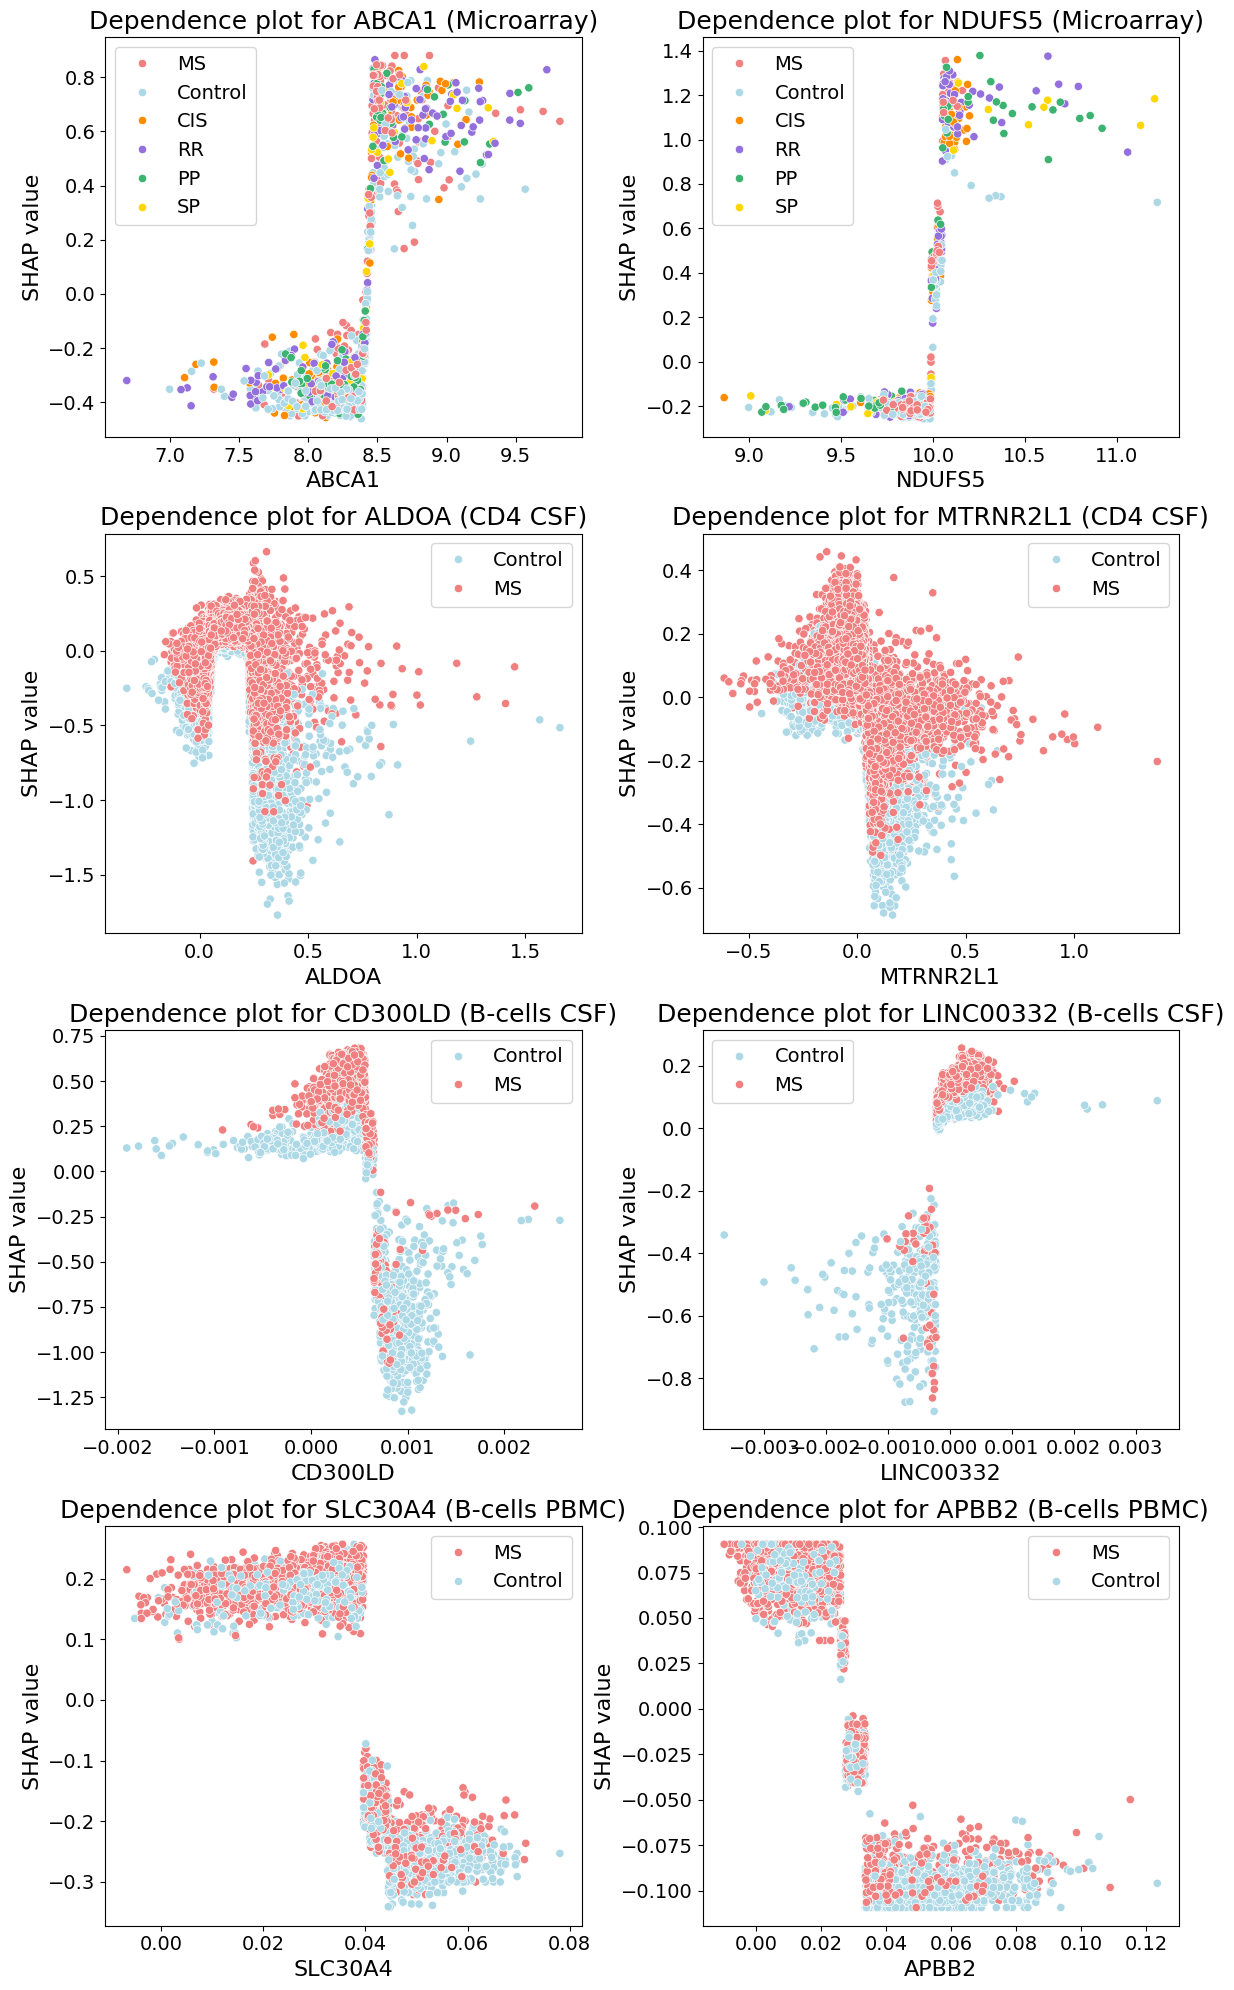

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
axes = axes.flatten()

# Reload microarray & map to construct condition
microarray = pd.read_csv("./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv")
map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")
map_microarray.rename(columns={"Label": "stage"}, inplace=True)
microarray_merged = pd.merge(microarray, map_microarray[["SampleID", "stage"]], on="SampleID", how="left")
microarray_merged["condition"] = np.where(microarray_merged["Label"] == 0, "Control", microarray_merged["stage"].fillna("MS"))

dependence_plot(
    df_expl=microarray_explanations,
    shap_object=microarray_shapObject,
    data=microarray.drop(columns=["SampleID", "PatientID", "Label"]),
    label_col=microarray["Label"].values,
    i=0,
    axes=axes,
    plot_title_suffix="(Microarray)",
    stage_col=microarray_merged["condition"].values,
)

dependence_plot(
    df_expl=cd4_csf_expl,
    shap_object=cd4_csf_shapObject,
    data=cd4_csf.X,
    label_col=cd4_csf.obs["condition"].apply(lambda x: 1 if x == "MS" else 0).values,
    i=2,
    axes=axes,
    type_data="singlecell",
    genes=cd4_csf.var_names,
    plot_title_suffix="(CD4 CSF)",
)

dependence_plot(
    df_expl=bcells_csf_expl,
    shap_object=bcells_csf_shapObject,
    data=bcells_csf.X,
    label_col=bcells_csf.obs["condition"].apply(lambda x: 1 if x == "MS" else 0).values,
    i=4,
    axes=axes,
    type_data="singlecell",
    genes=bcells_csf.var_names,
    plot_title_suffix="(B-cells CSF)",
)

dependence_plot(
    df_expl=bcells_pbmc_expl,
    shap_object=bcells_pbmc_shapObject,
    data=bcells_pbmc.X,
    label_col=bcells_pbmc.obs["condition"].apply(lambda x: 1 if x == "MS" else 0).values,
    i=6,
    axes=axes,
    type_data="singlecell",
    genes=bcells_pbmc.var_names,
    plot_title_suffix="(B-cells PBMC)",
)

plt.tight_layout()
plt.show()


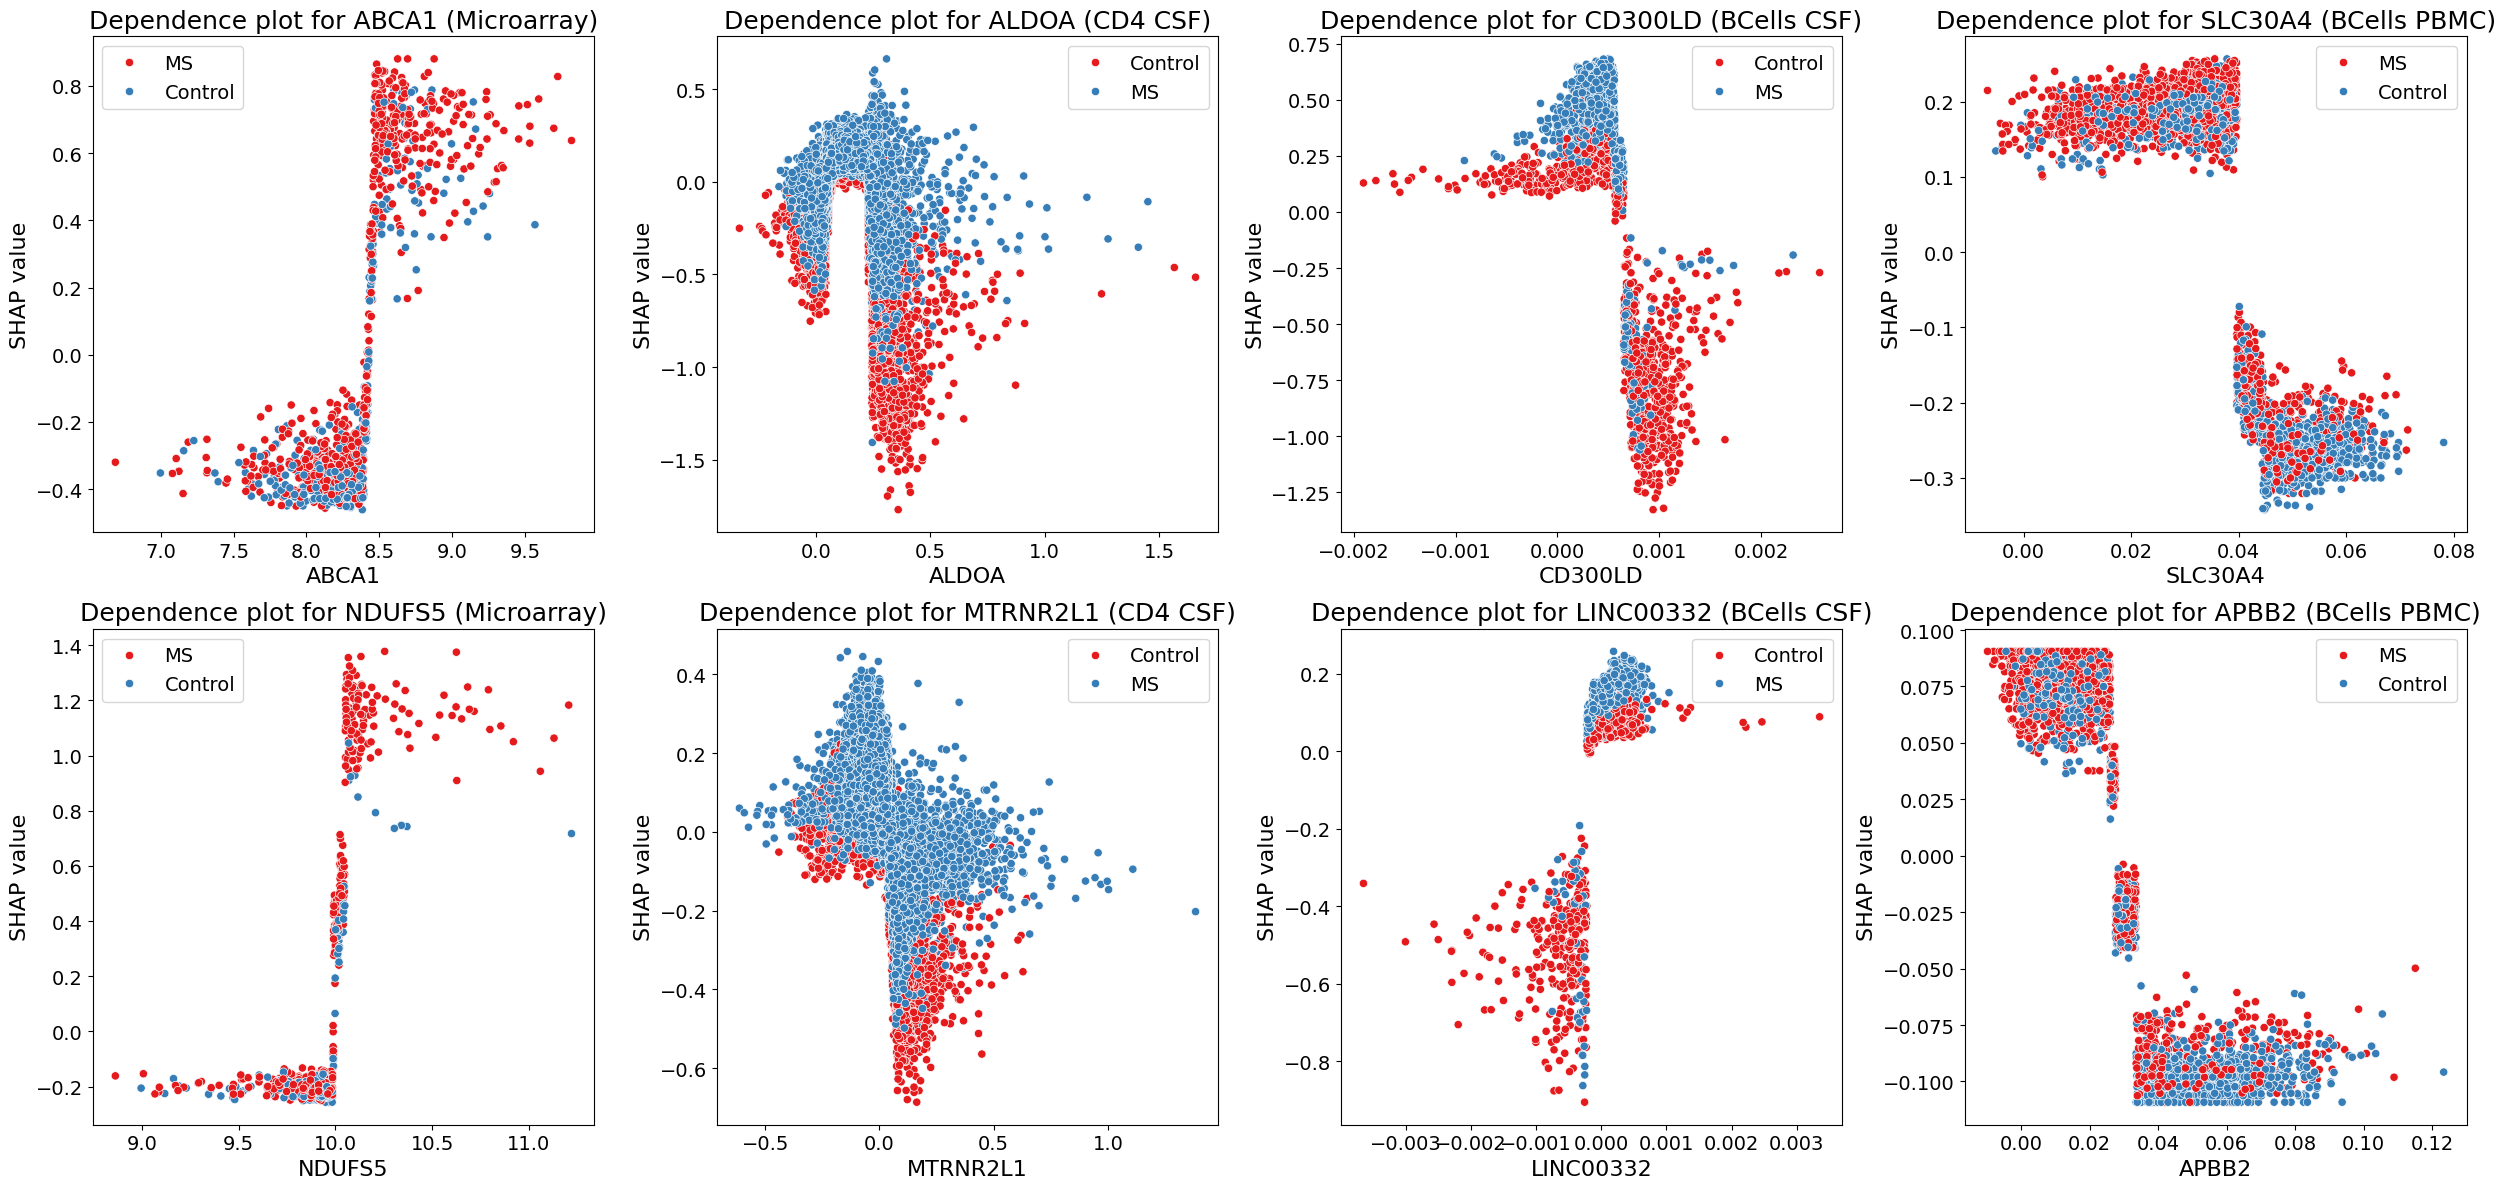

In [9]:
def dependence_plot_single(df_expl, shap_object, data, label_col, ax, feature_to_plot, type_data="microarray", genes=None, plot_title_suffix=""):
    if genes is None and type_data == "singlecell":
        raise ValueError("For 'singlecell' type_data, 'genes' parameter must be provided.")
    if genes is not None and not isinstance(genes, (list, pd.Index)):
        genes = list(genes)
    if isinstance(data, pd.DataFrame):
        current = data.copy()
        feature_names = current.columns
    elif type_data == "singlecell":
        X = data.toarray() if hasattr(data, 'toarray') else data
        current = pd.DataFrame(X, columns=genes)
        feature_names = genes
    else:
        raise TypeError("Unsupported 'data' type.")

    top_features = pd.DataFrame(df_expl).sort_values("MeanAbsoluteShap", ascending=False)["Feature"].values
    if feature_to_plot == 'top1':
        feature_name = top_features[0]
    elif feature_to_plot == 'top2':
        feature_name = top_features[1]
    else:
        raise ValueError("feature_to_plot must be 'top1' or 'top2'")

    idx_feature = list(feature_names).index(feature_name)
    shap_vals = shap_object.values[:, idx_feature]
    feature_vals = current.iloc[:, idx_feature].values
    customDf = pd.DataFrame({
        "SHAP": shap_vals,
        "Feature": feature_vals,
        "Label": ["MS" if value == 1 else "Control" for value in label_col],
    })
    sns.scatterplot(data=customDf, x="Feature", y="SHAP", hue="Label", palette="Set1", ax=ax)
    ax.set_title(f"Dependence plot for {feature_name} {plot_title_suffix}")
    ax.set_xlabel(f"{feature_name}")
    ax.set_ylabel("SHAP value")
    ax.legend()

fig, axes = plt.subplots(2, 4, figsize=(25, 12))
datasets_info = [
    {
        "df_expl": microarray_explanations,
        "shap_object": microarray_shapObject,
        "data": microarray.drop(columns=["SampleID", "PatientID", "Label"]),
        "label_col": microarray["Label"].values,
        "type_data": "microarray",
        "genes": None,
        "plot_title_suffix": "(Microarray)",
    },
    {
        "df_expl": cd4_csf_expl,
        "shap_object": cd4_csf_shapObject,
        "data": cd4_csf.X,
        "label_col": cd4_csf.obs["condition"].apply(lambda x: 1 if x == "MS" else 0).values,
        "type_data": "singlecell",
        "genes": cd4_csf.var_names,
        "plot_title_suffix": "(CD4 CSF)",
    },
    {
        "df_expl": bcells_csf_expl,
        "shap_object": bcells_csf_shapObject,
        "data": bcells_csf.X,
        "label_col": bcells_csf.obs["condition"].apply(lambda x: 1 if x == "MS" else 0).values,
        "type_data": "singlecell",
        "genes": bcells_csf.var_names,
        "plot_title_suffix": "(BCells CSF)",
    },
    {
        "df_expl": bcells_pbmc_expl,
        "shap_object": bcells_pbmc_shapObject,
        "data": bcells_pbmc.X,
        "label_col": bcells_pbmc.obs["condition"].apply(lambda x: 1 if x == "MS" else 0).values,
        "type_data": "singlecell",
        "genes": bcells_pbmc.var_names,
        "plot_title_suffix": "(BCells PBMC)",
    },
]
for col_idx, ds in enumerate(datasets_info):
    dependence_plot_single(
        df_expl=ds["df_expl"],
        shap_object=ds["shap_object"],
        data=ds["data"],
        label_col=ds["label_col"],
        ax=axes[0, col_idx],
        feature_to_plot='top1',
        type_data=ds["type_data"],
        genes=ds["genes"],
        plot_title_suffix=ds["plot_title_suffix"],
    )
for col_idx, ds in enumerate(datasets_info):
    dependence_plot_single(
        df_expl=ds["df_expl"],
        shap_object=ds["shap_object"],
        data=ds["data"],
        label_col=ds["label_col"],
        ax=axes[1, col_idx],
        feature_to_plot='top2',
        type_data=ds["type_data"],
        genes=ds["genes"],
        plot_title_suffix=ds["plot_title_suffix"],
    )
plt.tight_layout()
plt.show()


In [ ]:
def plot_samu(feature, dataset, shap_obj, subax, dataset_name):
    n_bins = 8
    index_feature = dataset.var_names.tolist().index(feature)
    X = dataset.X
    feature_values = X[:, index_feature].toarray().flatten() if hasattr(X, 'toarray') else X[:, index_feature]
    range_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
    bins = pd.Series(range_bins).apply(lambda x: f"[{x.left:.3f}–{x.right:.3f}]")
    shap_values = shap_obj.values[:, index_feature]
    conditions = dataset.obs.condition.values
    min_length = min(len(bins), len(shap_values), len(conditions))
    df_plot = pd.DataFrame({
        'shap_value': shap_values[:min_length],
        'expression_bin': bins[:min_length],
        'condition': conditions[:min_length]
    })
    palette = {'CTRL': 'lightblue', 'MS': 'lightcoral', 'Control': 'lightblue'}
    sns.boxplot(
        x='expression_bin', y='shap_value', hue='condition', data=df_plot,
        palette=palette, flierprops=dict(marker='o', color='black', markersize=4),
        boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'),
        capprops=dict(color='black'), medianprops=dict(color='black', linewidth=2),
        notch=True, ax=subax
    )
    subax.set_title(f'{feature} - {dataset_name}', fontsize=12, pad=10)
    subax.set_xlabel('Expression Bin', fontsize=10)
    subax.set_ylabel('SHAP Value', fontsize=10)
    subax.legend(title='Condition', fontsize=9)
    subax.tick_params(axis='x', rotation=45, labelsize=8)
    subax.tick_params(axis='y', labelsize=8)

def microarray_samu_plot(subax, feature):
    microarray = pd.read_csv("./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv")
    microarray_shapObject = joblib.load("./MICROARRAY/xgbDefFull_shapValues.pkl")
    map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")
    map_microarray.rename(columns={"Label": "stage"}, inplace=True)
    microarray_merged = pd.merge(microarray, map_microarray[["SampleID", "stage"]], on="SampleID", how="left")
    microarray_merged["condition"] = np.where(microarray_merged["Label"] == 0, "Control", microarray_merged["stage"].fillna("MS"))
    labels = microarray_merged["condition"]
    features_only = microarray.drop(columns=["SampleID", "PatientID", "Label"]).copy()
    n_bins = 8
    range_bins = pd.qcut(features_only[feature], q=n_bins, duplicates='drop')
    bins = pd.Series(range_bins).apply(lambda x: f"[{x.left:.1f}–{x.right:.1f}]")
    shap_values = microarray_shapObject.values[:, features_only.columns.get_loc(feature)]
    df_plot = pd.DataFrame({
        'shap_value': shap_values,
        'expression_bin': bins,
        'condition': labels,
    })
    palette = { 'Control': 'lightblue', 'MS': 'lightcoral', 'PP': 'mediumseagreen', 'RR': 'mediumpurple', 'SP': 'gold', 'CIS': 'darkorange' }
    hue_order = ["Control", "CIS", "RR", "SP", "PP", "MS"]
    sns.boxplot(
        x='expression_bin', y='shap_value', hue='condition', hue_order=hue_order,
        data=df_plot, palette=palette, flierprops=dict(marker='o', color='black', markersize=4),
        boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'),
        capprops=dict(color='black'), medianprops=dict(color='black', linewidth=2),
        notch=True, ax=subax
    )
    subax.set_title(f"{feature} - MICROARRAY", fontsize=12, pad=10)
    subax.set_xlabel("Expression Bin", fontsize=10)
    subax.set_ylabel("SHAP Value", fontsize=10)
    subax.legend(title='Condition', fontsize=9)
    subax.tick_params(axis='x', rotation=45, labelsize=8)
    subax.tick_params(axis='y', labelsize=8)

fig, axes = plt.subplots(2, 4, figsize=(48, 24))
axes = axes.flatten()
microarray_samu_plot(axes[0], "ABCA1")
microarray_samu_plot(axes[1], "NDUFS5")
plot_samu('ALDOA', cd4_csf, cd4_csf_shapObject, axes[2], "CD4_CSF")
plot_samu('MTRNR2L1', cd4_csf, cd4_csf_shapObject, axes[3], "CD4_CSF")
plot_samu('CD300LD', bcells_csf, bcells_csf_shapObject, axes[4], "BCELLS_CSF")
plot_samu('LRRC8E', bcells_csf, bcells_csf_shapObject, axes[5], "BCELLS_CSF")
plot_samu('SLC30A4', bcells_pbmc, bcells_pbmc_shapObject, axes[6], "BCELLS_PBMC")
plot_samu('APBB2', bcells_pbmc, bcells_pbmc_shapObject, axes[7], "BCELLS_PBMC")
plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
plt.suptitle("SHAP Values by Expression Bin and Condition Across Datasets", fontsize=16, y=0.98)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create figure with 3 rows (one per dataset) and 4 columns (one per gene)
fig, axes = plt.subplots(3, 4, figsize=(48, 36))

# Define the genes to plot
genes_to_plot = ['ABCA1', 'EIF2S2', 'WNT', 'RUNX1']

# Row 0: CD4_CSF
for col, gene in enumerate(genes_to_plot):
    try:
        plot_samu(gene, cd4_csf, cd4_csf_shapObject, axes[0, col], "CD4_CSF")
    except Exception as e:
        axes[0, col].text(0.5, 0.5, f'{gene}\nNot found in CD4_CSF', 
                         ha='center', va='center', fontsize=12)
        axes[0, col].set_title(f'{gene} - CD4_CSF (Not Available)', fontsize=12)

# Row 1: BCELLS_CSF
for col, gene in enumerate(genes_to_plot):
    try:
        plot_samu(gene, bcells_csf, bcells_csf_shapObject, axes[1, col], "BCELLS_CSF")
    except Exception as e:
        axes[1, col].text(0.5, 0.5, f'{gene}\nNot found in BCELLS_CSF', 
                         ha='center', va='center', fontsize=12)
        axes[1, col].set_title(f'{gene} - BCELLS_CSF (Not Available)', fontsize=12)

# Row 2: BCELLS_PBMC
for col, gene in enumerate(genes_to_plot):
    try:
        plot_samu(gene, bcells_pbmc, bcells_pbmc_shapObject, axes[2, col], "BCELLS_PBMC")
    except Exception as e:
        axes[2, col].text(0.5, 0.5, f'{gene}\nNot found in BCELLS_PBMC', 
                         ha='center', va='center', fontsize=12)
        axes[2, col].set_title(f'{gene} - BCELLS_PBMC (Not Available)', fontsize=12)

plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
plt.suptitle("SHAP Values by Expression Bin - Target Genes Across Single-Cell Datasets", 
             fontsize=18, y=0.995)
plt.show()


Notes:
- The notebook expects files under ../Store as referenced in the code.
- Some pickled filenames contain spaces (e.g., "xgbCSFBCELLS shapexplainer.pkl"). Ensure these exact filenames exist.
- If your feature-importance objects are not dict-like, adjust the construction of microarray_explanations accordingly.
- For AnnData.X being sparse, conversion to dense is handled for selected columns; ensure memory fits.


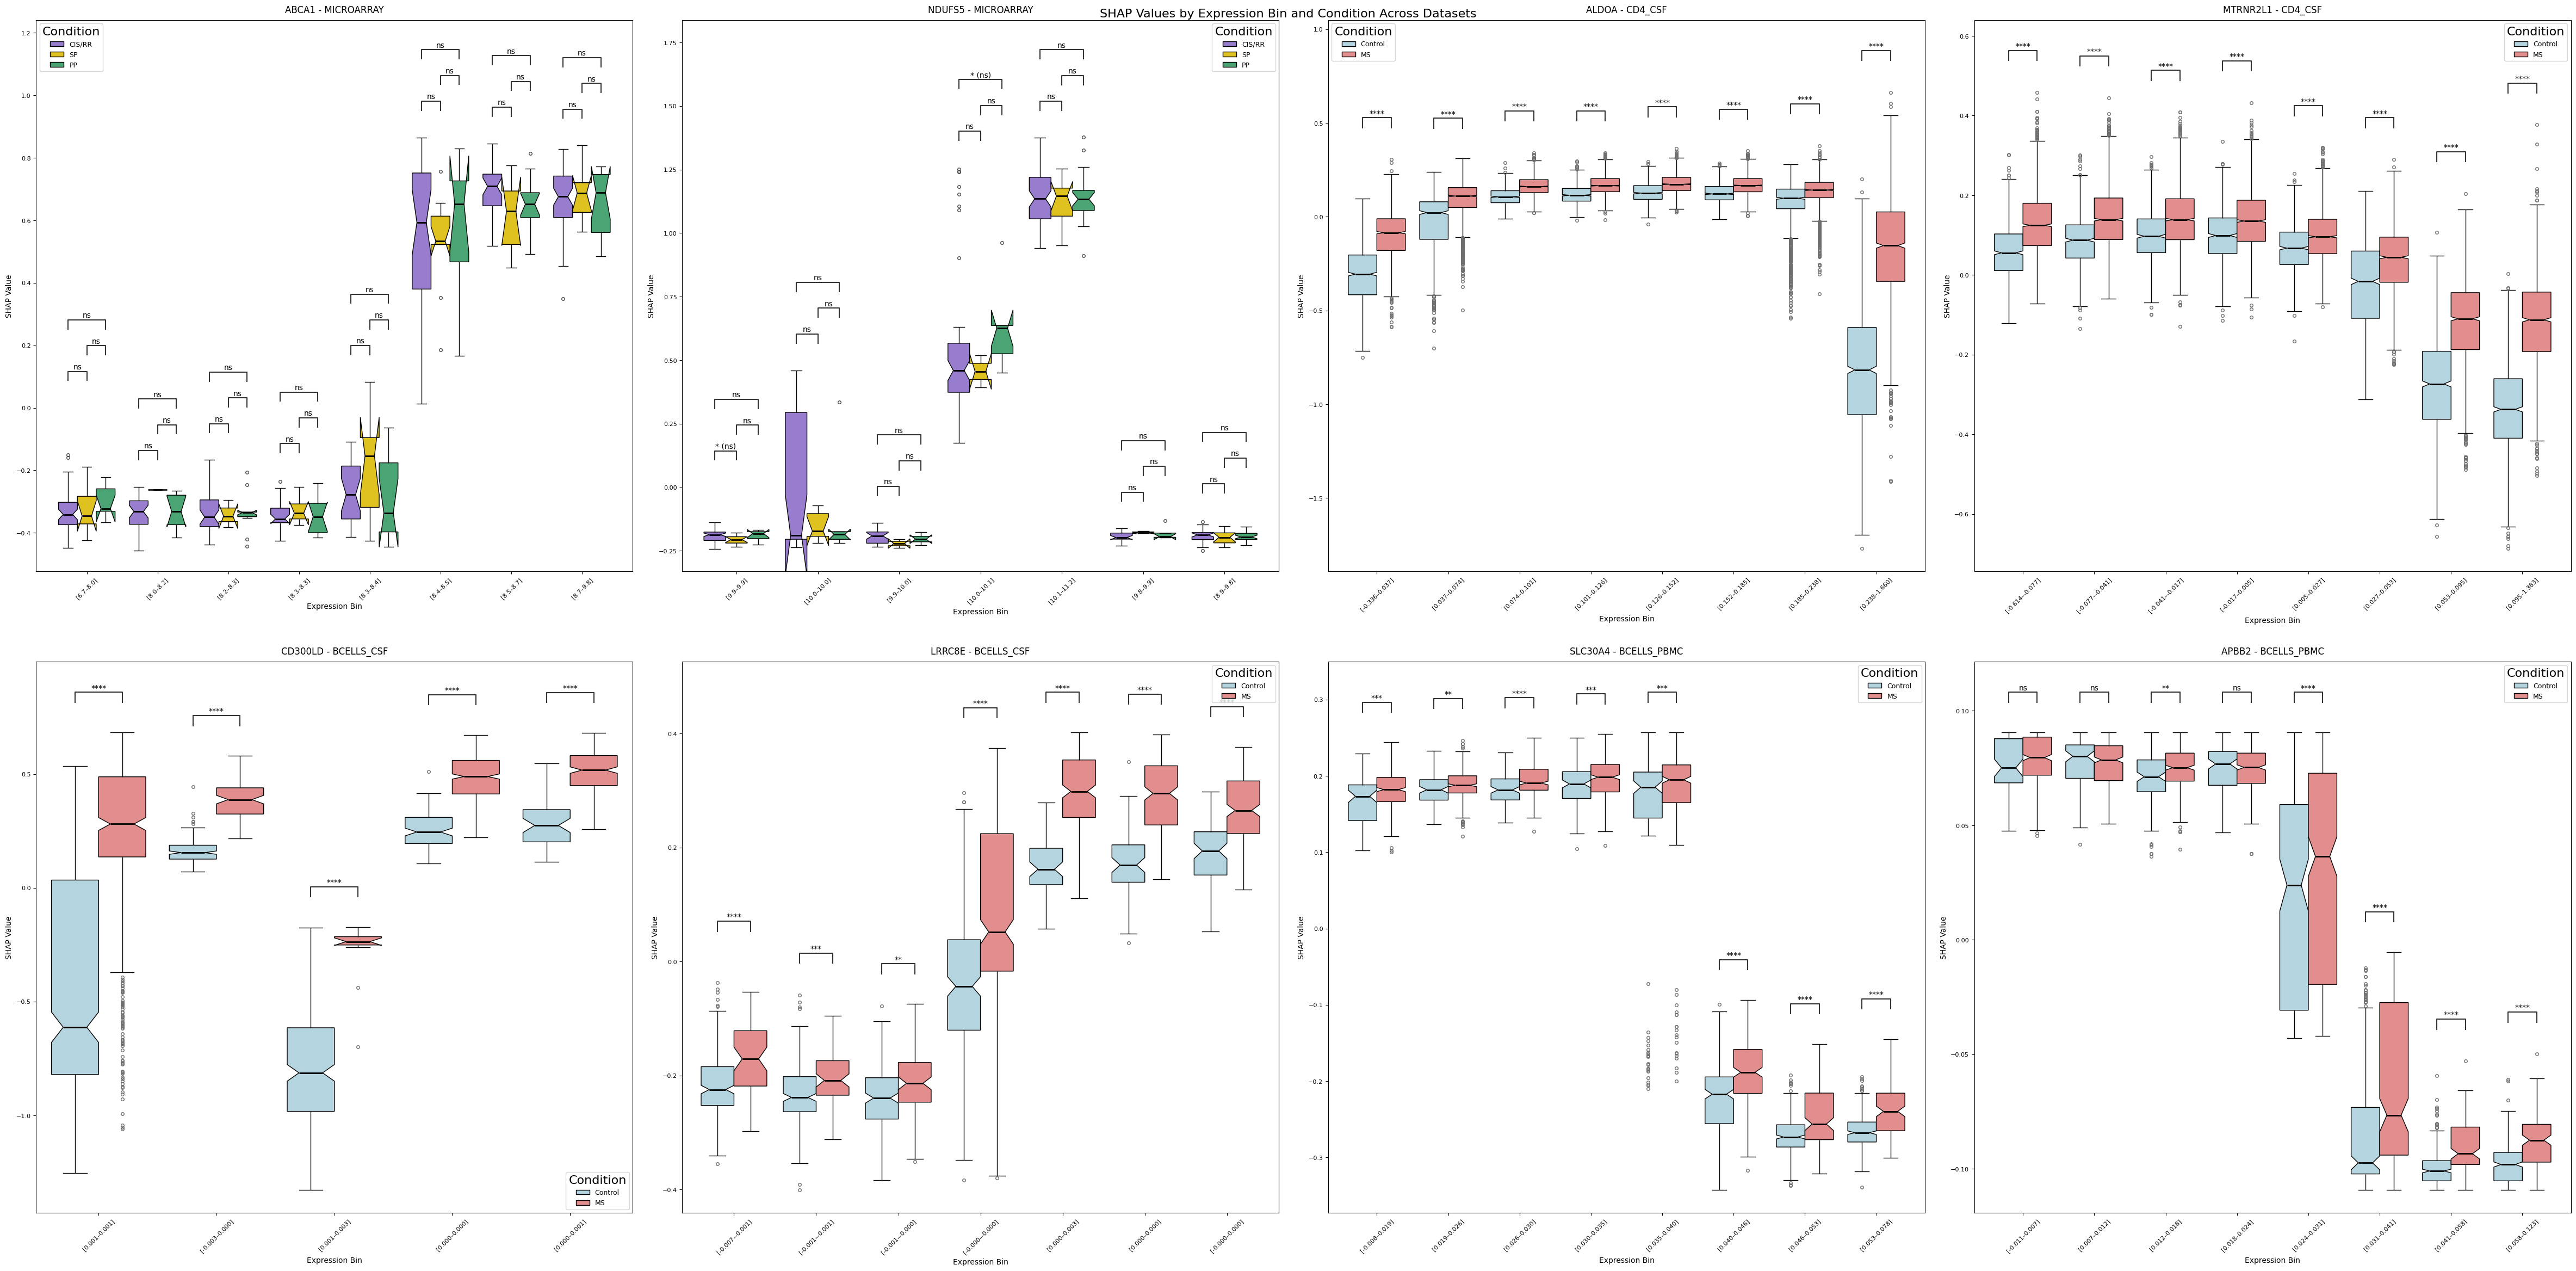

In [50]:

from statannotations.Annotator import Annotator
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


def microarray_samu_plot(subax, feature):
    """Plot SHAP values across expression bins for microarray data."""
    
    # Load microarray data
    microarray = pd.read_csv(
        "./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv"
    )
    microarray_shapObject = joblib.load("./MICROARRAY/xgbDefFull_shapValues.pkl")
    map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")
    
    # Prepare mapping
    map_microarray.rename(columns={"Label": "stage"}, inplace=True)
    
    # Merge and create condition column
    microarray_merged = pd.merge(
        microarray, map_microarray[["SampleID", "stage"]], on="SampleID", how="left"
    )
    microarray_merged["condition"] = np.where(
        microarray_merged["Label"] == 0,
        "Control",
        microarray_merged["stage"].fillna("MS"),
    )
    
    # Reset indices for clean alignment
    microarray_merged = microarray_merged.reset_index(drop=True)
    
    # Extract features and labels
    features_only = microarray.drop(
        columns=["SampleID", "PatientID", "Label"]
    ).copy().reset_index(drop=True)
    
    labels = microarray_merged["condition"].values
    
    # Create bins
    n_bins = 8
    feature_values = features_only[feature].values
    range_bins = pd.qcut(feature_values, q=n_bins, duplicates="drop")
    
    # Convert bins to string labels with explicit index reset
    bins = pd.Series(range_bins).reset_index(drop=True).apply(
        lambda x: f"[{x.left:.1f}–{x.right:.1f}]"
    )
    
    # Extract SHAP values
    feature_col_index = features_only.columns.get_loc(feature)
    shap_values = microarray_shapObject.values[:, feature_col_index]
    
    # Ensure all arrays have same length
    n_samples = min(len(shap_values), len(bins), len(labels))
    
    # Create dataframe with proper alignment
    df_plot = pd.DataFrame(
        {
            "shap_value": shap_values[:n_samples],
            "expression_bin": bins.values[:n_samples],
            "condition": labels[:n_samples],
        },
        index=range(n_samples)
    )
    df_plot["condition"] = df_plot["condition"].replace({"CIS":"CIS/RR", "RR":"CIS/RR"})
    keep_conditions = ["PP", "SP", "CIS/RR"]
    df_plot = df_plot[df_plot["condition"].isin(keep_conditions)]
    
    # Define palette and order
    palette = {
        "PP": "mediumseagreen",
        "SP": "gold",
        "CIS/RR": "mediumpurple",
    }

    
    # Ensure only conditions present in data are in hue_order
    unique_conds = df_plot["condition"].unique()
    hue_order = ["CIS/RR", "SP", "PP"]
    # Generate the boxplot
    sns.boxplot(
        x="expression_bin",
        y="shap_value",
        hue="condition",
        hue_order=hue_order,  # <-- ADD THE HUE_ORDER PARAMETER //IMPORTANTE X ORDINE
        data=df_plot,
        palette=palette,
        flierprops=dict(marker="o", color="black", markersize=4),
        boxprops=dict(edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black", linewidth=2),
        notch=True,
        ax=subax,
    )

    subax.set_title(f"{feature} - MICROARRAY", fontsize=12, pad=10)
    subax.set_xlabel("Expression Bin", fontsize=10)
    subax.set_ylabel("SHAP Value", fontsize=10)
    subax.legend(title="Condition", fontsize=9)
    subax.tick_params(axis="x", rotation=45, labelsize=8)
    subax.tick_params(axis="y", labelsize=8)

    pairs = []
    for bin_label in df_plot["expression_bin"].unique():
        df_bin = df_plot[df_plot["expression_bin"] == bin_label]
        for i in range(len(hue_order)):
            for j in range(i + 1, len(hue_order)):
                cond_a = hue_order[i]
                cond_b = hue_order[j]
                if (
                    df_bin[df_bin["condition"] == cond_a].shape[0] > 0
                    and df_bin[df_bin["condition"] == cond_b].shape[0] > 0
                ):
                    pairs.append(((bin_label, cond_a), (bin_label, cond_b)))

    annotator = Annotator(
        subax, pairs,
        data=df_plot,
        x="expression_bin", 
        y="shap_value",
        hue="condition", 
        hue_order=hue_order,
        verbose=0
    )
    annotator.configure(
        test='Mann-Whitney',
        text_format='star',
        comparisons_correction='fdr_bh',
        loc='inside'
    )

    annotator.apply_and_annotate()



# Main plotting code
if __name__ == "__main__":
    fig, axes = plt.subplots(2, 4, figsize=(48, 24))
    axes = axes.flatten()
    
    try:
        microarray_samu_plot(axes[0], "ABCA1")
        microarray_samu_plot(axes[1], "NDUFS5")
        plot_samu('ALDOA', cd4_csf, cd4_csf_shapObject, axes[2], "CD4_CSF")
        plot_samu('MTRNR2L1', cd4_csf, cd4_csf_shapObject, axes[3], "CD4_CSF")
        plot_samu('CD300LD', bcells_csf, bcells_csf_shapObject, axes[4], "BCELLS_CSF")
        plot_samu('LRRC8E', bcells_csf, bcells_csf_shapObject, axes[5], "BCELLS_CSF")
        plot_samu('SLC30A4', bcells_pbmc, bcells_pbmc_shapObject, axes[6], "BCELLS_PBMC")
        plot_samu('APBB2', bcells_pbmc, bcells_pbmc_shapObject, axes[7], "BCELLS_PBMC")
        
        plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
        plt.suptitle("SHAP Values by Expression Bin and Condition Across Datasets", 
                     fontsize=16, y=0.98)
        plt.savefig("ioodioquestoplot.png")

        plt.show()
    except Exception as e:
        print(f"Error during plotting: {e}")
        import traceback
        traceback.print_exc()

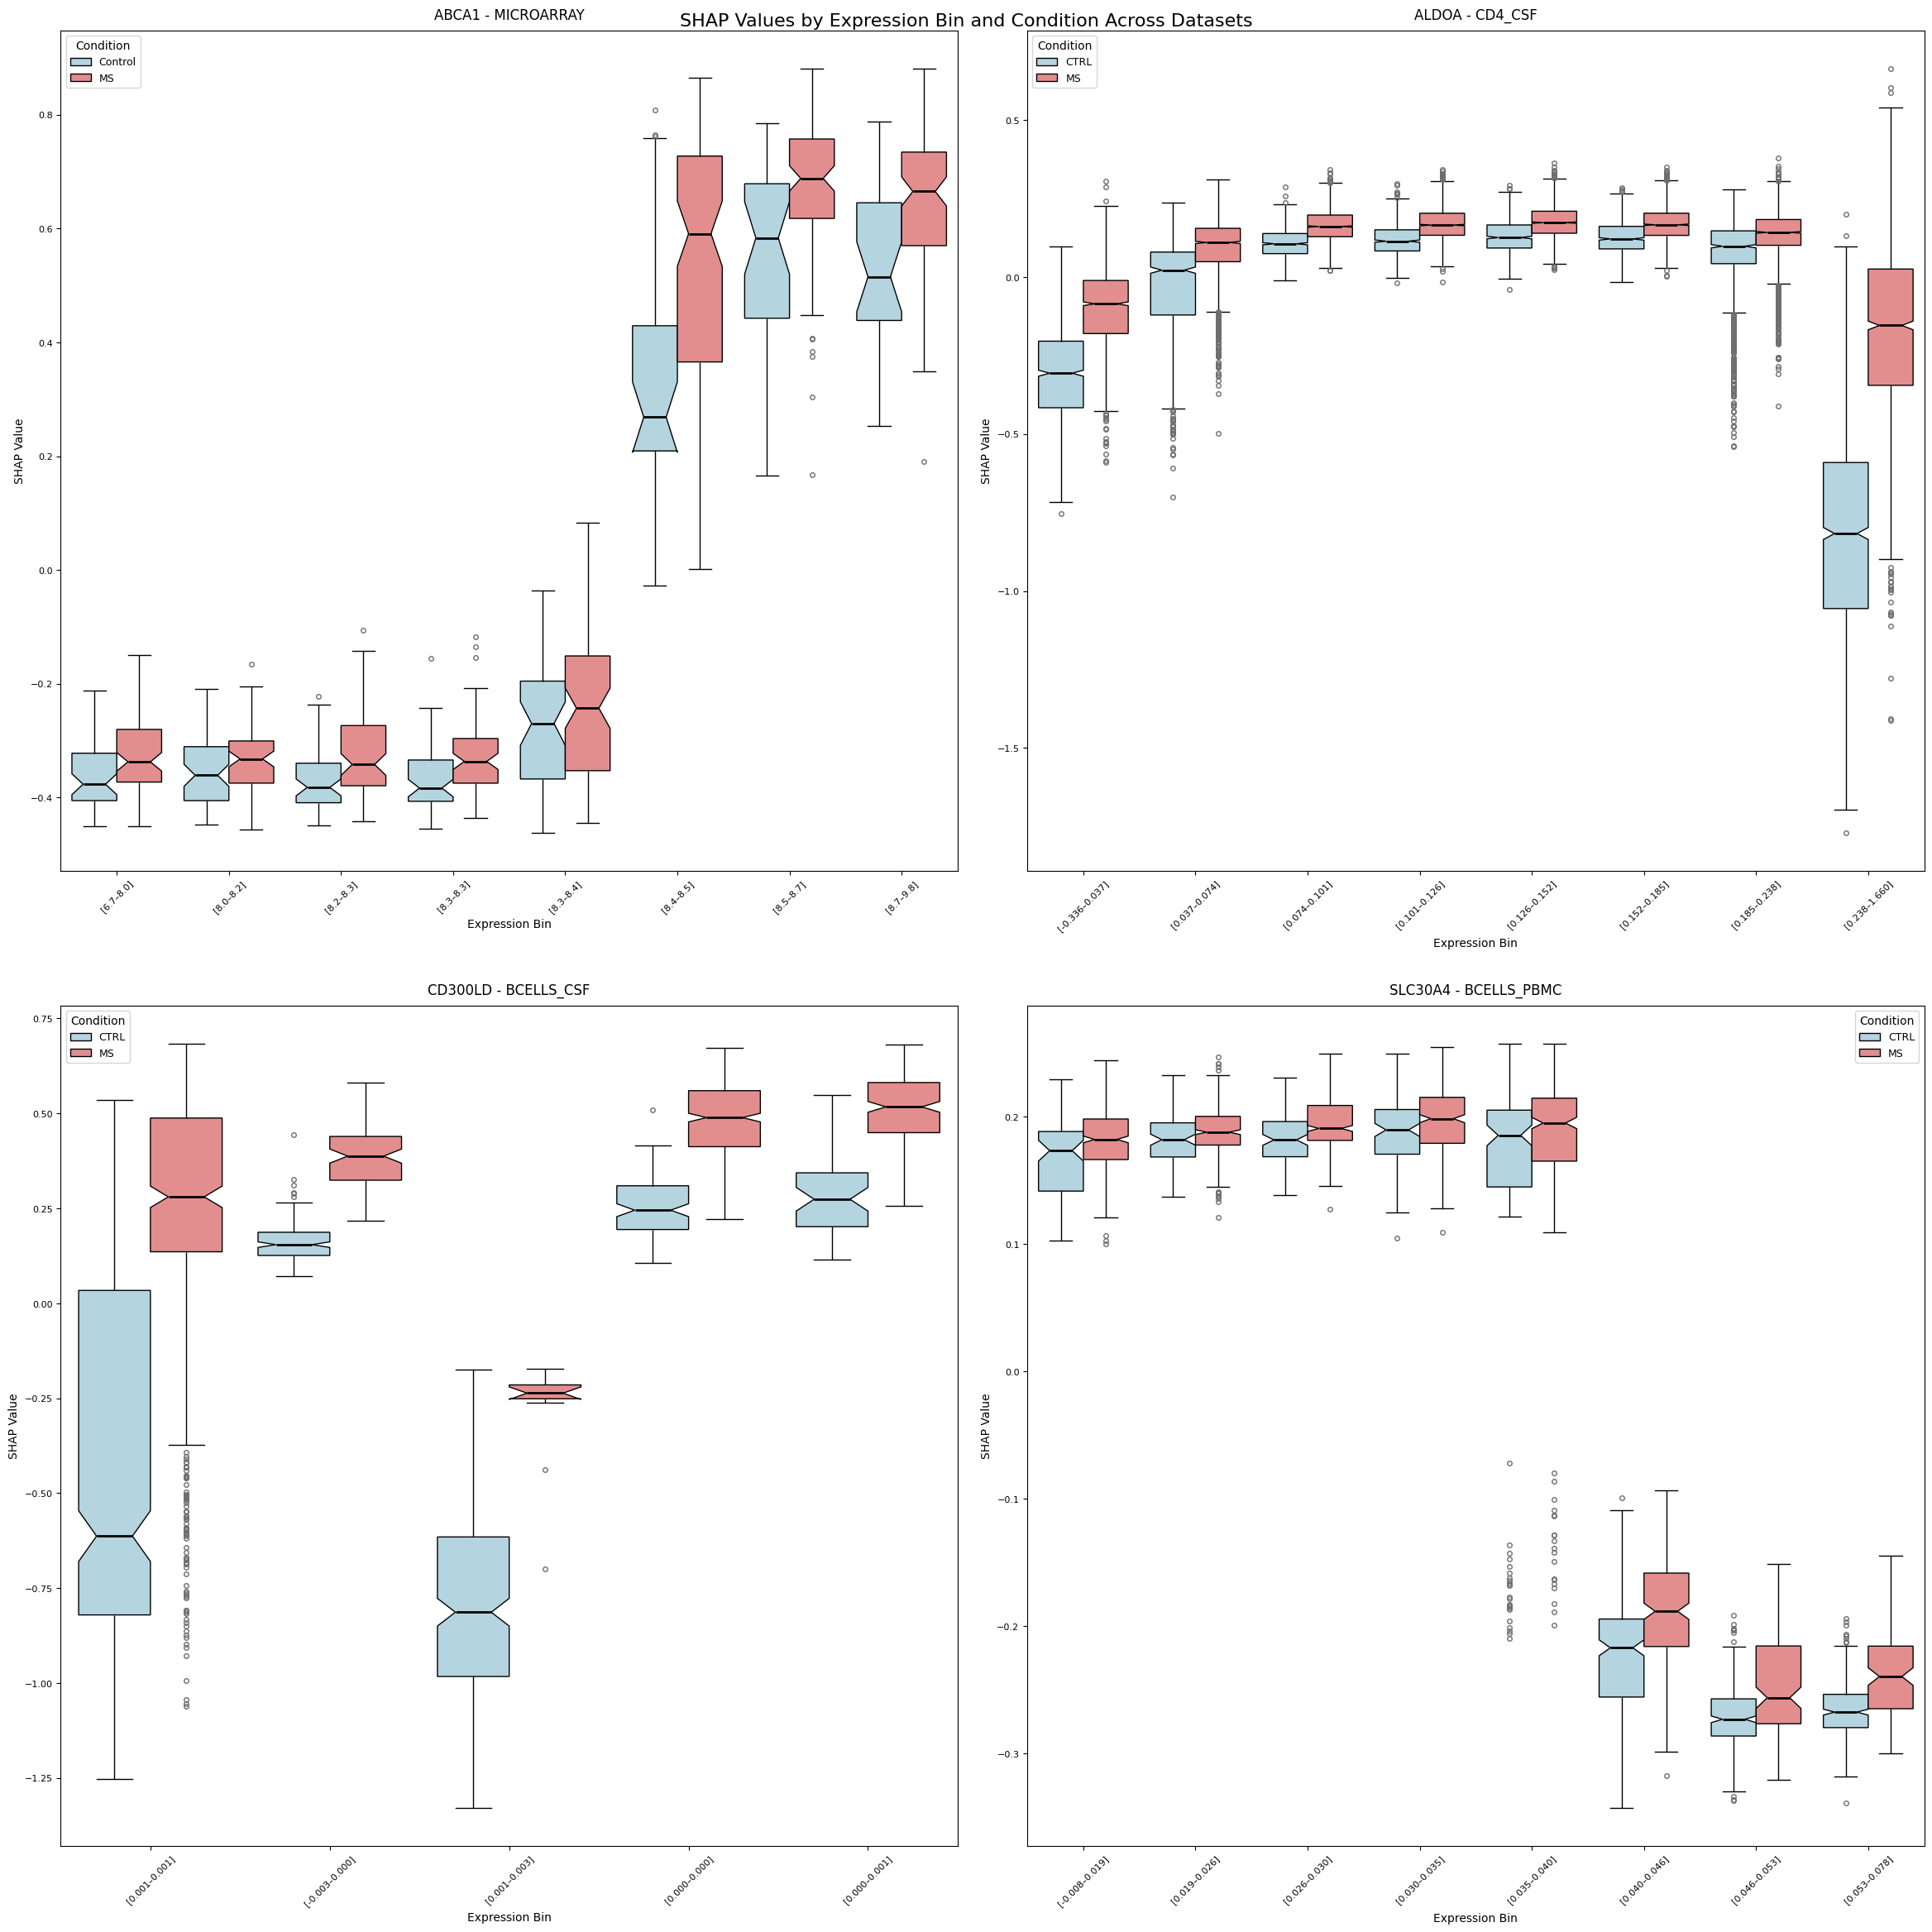

In [6]:
def plot_samu(feature, dataset, shap_obj, subax, dataset_name):
    n_bins = 8
    index_feature = dataset.var_names.tolist().index(feature)
    X = dataset.X
    feature_values = X[:, index_feature].toarray().flatten() if hasattr(X, 'toarray') else X[:, index_feature]
    
    # Handle binning with duplicates
    try:
        range_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
    except ValueError:
        # If 8 bins fail, try fewer bins
        n_bins = 5
        range_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
    
    bins = pd.Series(range_bins).apply(lambda x: f"[{x.left:.3f}–{x.right:.3f}]")
    shap_values = shap_obj.values[:, index_feature]
    conditions = dataset.obs.condition.values
    min_length = min(len(bins), len(shap_values), len(conditions))
    
    df_plot = pd.DataFrame({
        'shap_value': shap_values[:min_length],
        'expression_bin': bins[:min_length],
        'condition': conditions[:min_length]
    })
    
    palette = {'CTRL': 'lightblue', 'MS': 'lightcoral', 'Control': 'lightblue'}
    
    sns.boxplot(
        x='expression_bin', y='shap_value', hue='condition', data=df_plot,
        palette=palette, flierprops=dict(marker='o', color='black', markersize=4),
        boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'),
        capprops=dict(color='black'), medianprops=dict(color='black', linewidth=2),
        notch=True, ax=subax
    )
    
    subax.set_title(f'{feature} - {dataset_name}', fontsize=12, pad=10)
    subax.set_xlabel('Expression Bin', fontsize=10)
    subax.set_ylabel('SHAP Value', fontsize=10)
    subax.legend(title='Condition', fontsize=9)
    subax.tick_params(axis='x', rotation=45, labelsize=8)
    subax.tick_params(axis='y', labelsize=8)


def microarray_samu_plot(subax, feature):
    microarray = pd.read_csv("./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv")
    microarray_shapObject = joblib.load("./MICROARRAY/xgbDefFull_shapValues.pkl")
    map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")
    map_microarray.rename(columns={"Label": "stage"}, inplace=True)
    
    microarray_merged = pd.merge(microarray, map_microarray[["SampleID", "stage"]], on="SampleID", how="left")
    
    # Simplify to MS vs Control only (no individual stages)
    microarray_merged["condition"] = np.where(
        microarray_merged["Label"] == 0, 
        "Control", 
        "MS"  # All non-control samples are "MS"
    )
    
    labels = microarray_merged["condition"]
    features_only = microarray.drop(columns=["SampleID", "PatientID", "Label"]).copy()
    
    n_bins = 8
    range_bins = pd.qcut(features_only[feature], q=n_bins, duplicates='drop')
    bins = pd.Series(range_bins).apply(lambda x: f"[{x.left:.1f}–{x.right:.1f}]")
    shap_values = microarray_shapObject.values[:, features_only.columns.get_loc(feature)]
    
    df_plot = pd.DataFrame({
        'shap_value': shap_values,
        'expression_bin': bins,
        'condition': labels,
    })
    
    # Simplified palette: only MS and Control
    palette = {'Control': 'lightblue', 'MS': 'lightcoral'}
    hue_order = ["Control", "MS"]
    
    sns.boxplot(
        x='expression_bin', y='shap_value', hue='condition', hue_order=hue_order,
        data=df_plot, palette=palette, flierprops=dict(marker='o', color='black', markersize=4),
        boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'),
        capprops=dict(color='black'), medianprops=dict(color='black', linewidth=2),
        notch=True, ax=subax
    )
    
    subax.set_title(f"{feature} - MICROARRAY", fontsize=12, pad=10)
    subax.set_xlabel("Expression Bin", fontsize=10)
    subax.set_ylabel("SHAP Value", fontsize=10)
    subax.legend(title='Condition', fontsize=9)
    subax.tick_params(axis='x', rotation=45, labelsize=8)
    subax.tick_params(axis='y', labelsize=8)


# Create 2x2 layout (4 plots total)
fig, axes = plt.subplots(2, 2, figsize=(24, 24))
axes = axes.flatten()

# Top row
microarray_samu_plot(axes[0], "ABCA1")
plot_samu('ALDOA', cd4_csf, cd4_csf_shapObject, axes[1], "CD4_CSF")

# Bottom row
plot_samu('CD300LD', bcells_csf, bcells_csf_shapObject, axes[2], "BCELLS_CSF")
plot_samu('SLC30A4', bcells_pbmc, bcells_pbmc_shapObject, axes[3], "BCELLS_PBMC")

plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
plt.suptitle("SHAP Values by Expression Bin and Condition Across Datasets", fontsize=16, y=0.98)
plt.show()


✓ Saved: figure5_final_rank.png


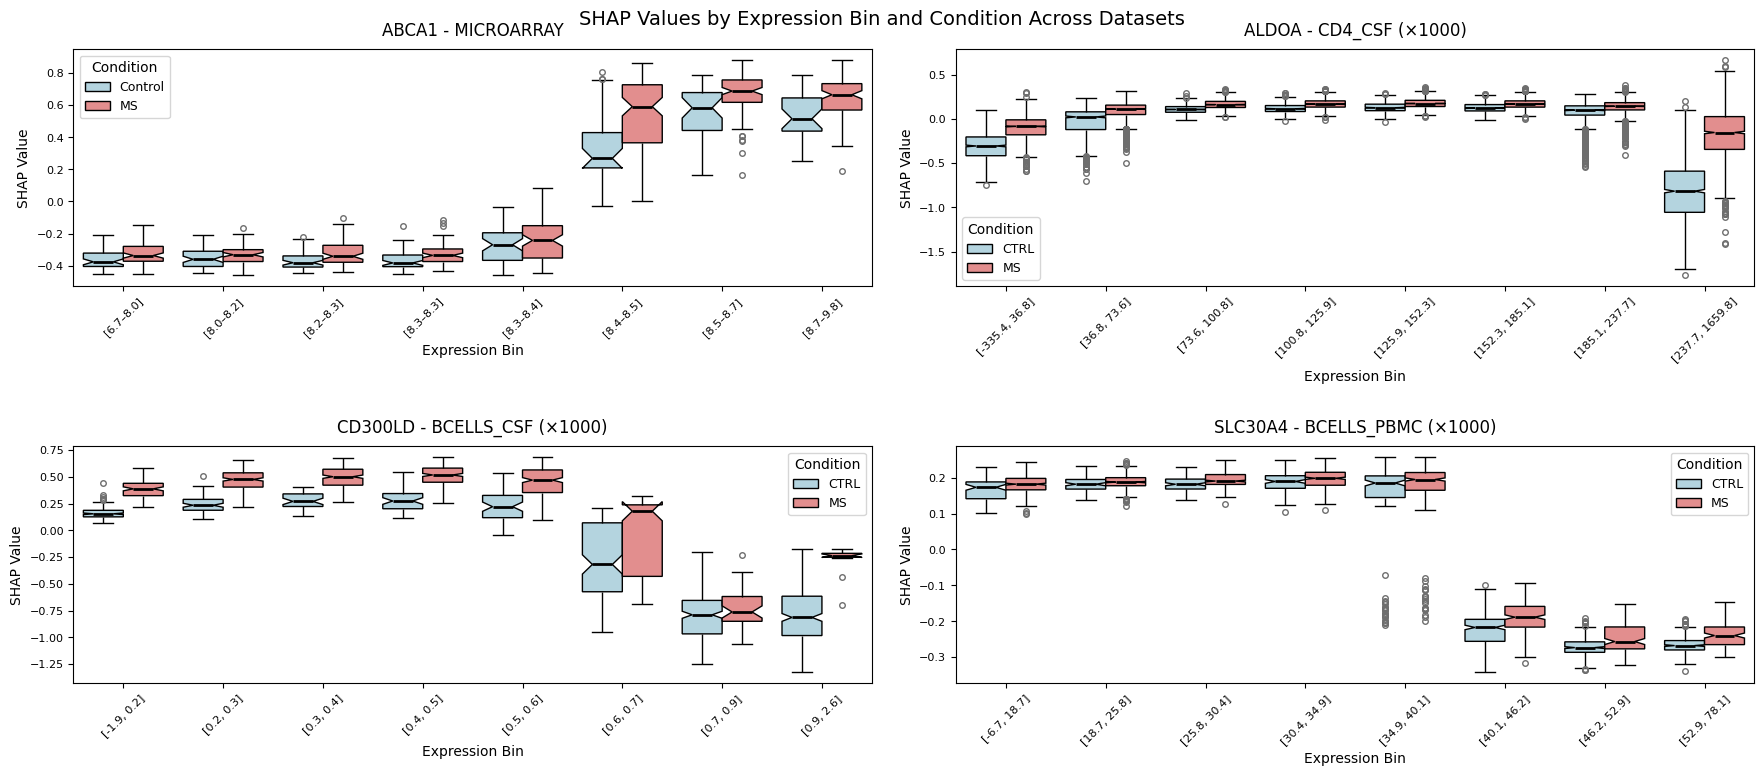

In [11]:
# ==================== OPTION 1: SCALED EXPRESSION ====================
def plot_samu_scaled(feature, dataset, shap_obj, subax, dataset_name, scale=1000):
    n_bins = 8
    index_feature = dataset.var_names.tolist().index(feature)
    X = dataset.X
    feature_values = X[:, index_feature].toarray().flatten() if hasattr(X, 'toarray') else X[:, index_feature]
    
    # Scale expression values
    scaled_values = feature_values * scale
    
    try:
        range_bins = pd.qcut(scaled_values, q=n_bins, duplicates='drop')
    except ValueError:
        range_bins = pd.qcut(scaled_values, q=5, duplicates='drop')
    
    bins = pd.Series(range_bins).apply(lambda x: f"[{x.left:.1f}, {x.right:.1f}]")
    shap_values = shap_obj.values[:, index_feature]
    conditions = dataset.obs.condition.values
    min_length = min(len(bins), len(shap_values), len(conditions))
    
    df_plot = pd.DataFrame({
        'shap_value': shap_values[:min_length],
        'expression_bin': bins[:min_length],
        'condition': conditions[:min_length]
    })
    
    palette = {'CTRL': 'lightblue', 'MS': 'lightcoral', 'Control': 'lightblue'}
    sns.boxplot(x='expression_bin', y='shap_value', hue='condition', data=df_plot,
                palette=palette, notch=True, ax=subax,
                flierprops=dict(marker='o', color='black', markersize=4),
                boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'),
                capprops=dict(color='black'), medianprops=dict(color='black', linewidth=2))
    
    subax.set_title(f'{feature} - {dataset_name} (×{scale})', fontsize=12, pad=10)
    subax.set_xlabel('Expression Bin', fontsize=10)
    subax.set_ylabel('SHAP Value', fontsize=10)
    subax.legend(title='Condition', fontsize=9)
    subax.tick_params(axis='x', rotation=45, labelsize=8)
    subax.tick_params(axis='y', labelsize=8)


# ==================== OPTION 3: RANK LABELS (FIXED) ====================
def plot_samu_rank(feature, dataset, shap_obj, subax, dataset_name):
    n_bins = 8
    index_feature = dataset.var_names.tolist().index(feature)
    X = dataset.X
    feature_values = X[:, index_feature].toarray().flatten() if hasattr(X, 'toarray') else X[:, index_feature]
    
    try:
        range_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
    except ValueError:
        range_bins = pd.qcut(feature_values, q=5, duplicates='drop')
    
    # Simple rank labels - FIXED
    bins_series = pd.Series(range_bins)
    n_actual_bins = bins_series.nunique()
    labels = ["Low"] + [f"Q{i+2}" for i in range(n_actual_bins-2)] + ["High"]
    
    # Create mapping from intervals to labels
    unique_intervals = sorted(bins_series.unique())
    bin_map = {interval: labels[i] for i, interval in enumerate(unique_intervals)}
    bins = bins_series.map(bin_map)
    
    shap_values = shap_obj.values[:, index_feature]
    conditions = dataset.obs.condition.values
    min_length = min(len(bins), len(shap_values), len(conditions))
    
    df_plot = pd.DataFrame({
        'shap_value': shap_values[:min_length],
        'expression_bin': bins[:min_length],
        'condition': conditions[:min_length]
    })
    
    palette = {'CTRL': 'lightblue', 'MS': 'lightcoral', 'Control': 'lightblue'}
    sns.boxplot(x='expression_bin', y='shap_value', hue='condition', data=df_plot,
                order=labels, palette=palette, notch=True, ax=subax,
                flierprops=dict(marker='o', color='black', markersize=4),
                boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'),
                capprops=dict(color='black'), medianprops=dict(color='black', linewidth=2))
    
    subax.set_title(f'{feature} - {dataset_name}', fontsize=12, pad=10)
    subax.set_xlabel('Expression Level', fontsize=10)
    subax.set_ylabel('SHAP Value', fontsize=10)
    subax.legend(title='Condition', fontsize=9)
    subax.tick_params(axis='x', rotation=45, labelsize=10)
    subax.tick_params(axis='y', labelsize=8)


# ==================== USAGE ====================
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()

# Option 3: Rank (Recommended)
microarray_samu_plot(axes[0], "ABCA1")
plot_samu_scaled('ALDOA', cd4_csf, cd4_csf_shapObject, axes[1], "CD4_CSF")
plot_samu_scaled('CD300LD', bcells_csf, bcells_csf_shapObject, axes[2], "BCELLS_CSF")
plot_samu_scaled('SLC30A4', bcells_pbmc, bcells_pbmc_shapObject, axes[3], "BCELLS_PBMC")

plt.tight_layout(pad=2.0, h_pad=2.5, w_pad=2.0)
plt.suptitle("SHAP Values by Expression Bin and Condition Across Datasets", fontsize=14)
# SAVE THE FIGURE
output_path = "figure5_final_rank.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")


plt.show()


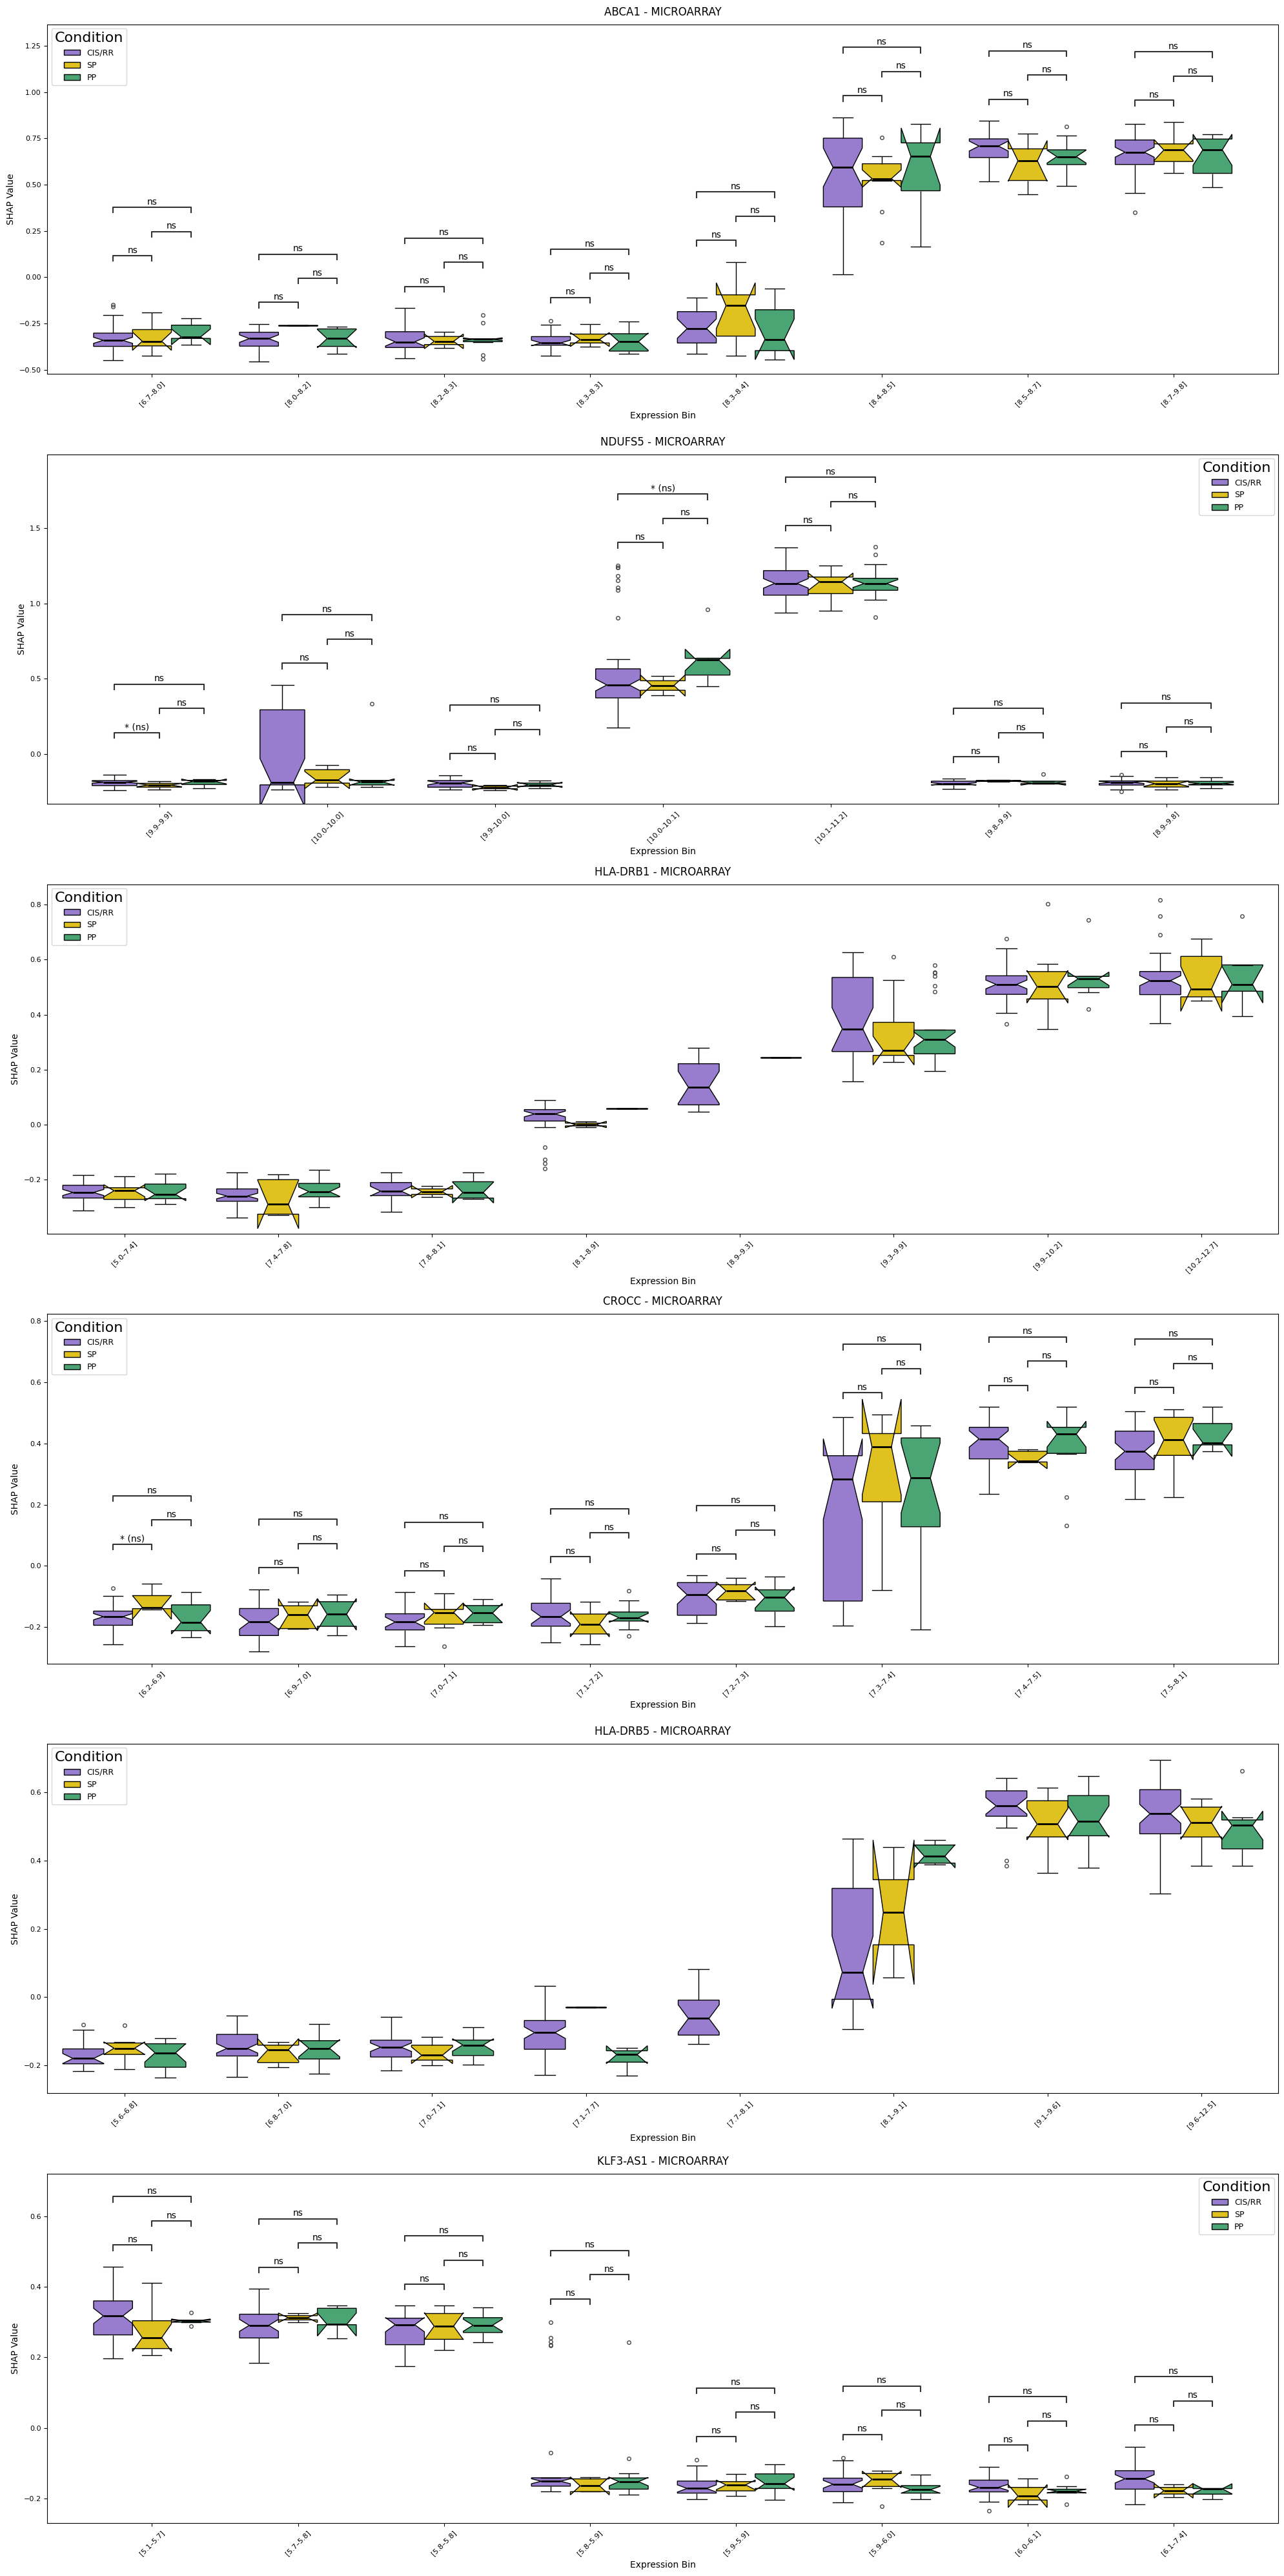

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from statannotations.Annotator import Annotator

def microarray_samu_plot(subax, gene):
    # Load the data files
    microarray = pd.read_csv(
        "./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv"
    )
    microarray_shapObject = joblib.load("./MICROARRAY/xgbDefFull_shapValues.pkl")
    map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")

    map_microarray.rename(columns={"Label": "stage"}, inplace=True)

    microarray_merged = pd.merge(
        microarray,
        map_microarray[["SampleID", "stage"]],
        on="SampleID",
        how="left",
    )

    microarray_merged["condition"] = np.where(
        microarray_merged["Label"] == 0,
        "Control",
        microarray_merged["stage"].fillna("MS"),
    )
    labels = microarray_merged["condition"].values

    microarray.drop(columns=["SampleID", "PatientID", "Label"], inplace=True)

    feature = gene
    n_bins = 8
    range_bins = pd.qcut(microarray[feature], q=n_bins, duplicates="drop")
    
    bins = pd.Series(range_bins).apply(lambda x: f"[{x.left:.1f}–{x.right:.1f}]").values
    shap_values = microarray_shapObject.values[:, microarray.columns.get_loc(feature)]

    # CRITICAL FIX: Use pd.isna() instead of np.isnan()
    valid_mask = (
        ~pd.isna(shap_values) & 
        ~pd.isna(bins) & 
        ~pd.isna(labels)
    )
    
    df_plot = pd.DataFrame(
        {
            "shap_value": shap_values[valid_mask],
            "expression_bin": bins[valid_mask],
            "condition": labels[valid_mask],
        }
    )

    df_plot["condition"] = df_plot["condition"].replace(
        {"CIS": "CIS/RR", "RR": "CIS/RR"}
    )

    keep_conditions = ["PP", "SP", "CIS/RR"]
    df_plot = df_plot[df_plot["condition"].isin(keep_conditions)]

    if df_plot.empty:
        print(f"Warning: No data for {gene}")
        return

    palette = {
        "PP": "mediumseagreen",
        "SP": "gold",
        "CIS/RR": "mediumpurple",
    }

    hue_order = ["CIS/RR", "SP", "PP"]

    sns.boxplot(
        x="expression_bin",
        y="shap_value",
        hue="condition",
        hue_order=hue_order,
        data=df_plot,
        palette=palette,
        flierprops=dict(marker="o", color="black", markersize=4),
        boxprops=dict(edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black", linewidth=2),
        notch=True,
        ax=subax,
    )

    subax.set_title(f"{gene} - MICROARRAY", fontsize=12, pad=10)
    subax.set_xlabel("Expression Bin", fontsize=10)
    subax.set_ylabel("SHAP Value", fontsize=10)
    subax.legend(title="Condition", fontsize=9)
    subax.tick_params(axis="x", rotation=45, labelsize=8)
    subax.tick_params(axis="y", labelsize=8)

    bin_labels = sorted(df_plot["expression_bin"].unique())
    pairs = []
    for bin_label in bin_labels:
        for i, cond1 in enumerate(hue_order):
            for cond2 in hue_order[i+1:]:
                pairs.append(((bin_label, cond1), (bin_label, cond2)))

    if pairs:
        try:
            annotator = Annotator(
                subax, pairs,
                data=df_plot,
                x="expression_bin", 
                y="shap_value",
                hue="condition", 
                hue_order=hue_order,
                verbose=0
            )
            annotator.configure(
                test='Mann-Whitney',
                text_format='star',
                comparisons_correction='fdr_bh',
                loc='inside'
            )
            annotator.apply_and_annotate()
        except Exception as e:
            print(f"Warning: Annotations failed for {gene}: {str(e)}")

fig, axes = plt.subplots(6, 1, figsize=(20, 40))
axes = axes.flatten()

microarray_samu_plot(axes[0], 'ABCA1')
microarray_samu_plot(axes[1], 'NDUFS5')
microarray_samu_plot(axes[2], 'HLA-DRB1')
microarray_samu_plot(axes[3], 'CROCC')
microarray_samu_plot(axes[4], 'HLA-DRB5')
microarray_samu_plot(axes[5], 'KLF3-AS1')

plt.tight_layout()
plt.savefig("plotfinale.png")


In [ ]:

from statannotations.Annotator import Annotator
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


def microarray_samu_plot(subax, feature):
    """Plot SHAP values across expression bins for microarray data."""
    
    # Load microarray data
    microarray = pd.read_csv(
        "./MICROARRAY/MergedDatasetFullCombatDeclustered_symbol.csv"
    )
    microarray_shapObject = joblib.load("./MICROARRAY/xgbDefFull_shapValues.pkl")
    map_microarray = pd.read_csv("./MICROARRAY/patientMap.csv")
    
    # Prepare mapping
    map_microarray.rename(columns={"Label": "stage"}, inplace=True)
    
    # Merge and create condition column
    microarray_merged = pd.merge(
        microarray, map_microarray[["SampleID", "stage"]], on="SampleID", how="left"
    )
    microarray_merged["condition"] = np.where(
        microarray_merged["Label"] == 0,
        "Control",
        microarray_merged["stage"].fillna("MS"),
    )
    
    # Reset indices for clean alignment
    microarray_merged = microarray_merged.reset_index(drop=True)
    
    # Extract features and labels
    features_only = microarray.drop(
        columns=["SampleID", "PatientID", "Label"]
    ).copy().reset_index(drop=True)
    
    labels = microarray_merged["condition"].values
    
    # Create bins
    n_bins = 8
    feature_values = features_only[feature].values
    range_bins = pd.qcut(feature_values, q=n_bins, duplicates="drop")
    
    # Convert bins to string labels with explicit index reset
    bins = pd.Series(range_bins).reset_index(drop=True).apply(
        lambda x: f"[{x.left:.1f}–{x.right:.1f}]"
    )
    
    # Extract SHAP values
    feature_col_index = features_only.columns.get_loc(feature)
    shap_values = microarray_shapObject.values[:, feature_col_index]
    
    # Ensure all arrays have same length
    n_samples = min(len(shap_values), len(bins), len(labels))
    
    # Create dataframe with proper alignment
    df_plot = pd.DataFrame(
        {
            "shap_value": shap_values[:n_samples],
            "expression_bin": bins.values[:n_samples],
            "condition": labels[:n_samples],
        },
        index=range(n_samples)
    )
    df_plot["condition"] = df_plot["condition"].replace({"CIS":"CIS/RR", "RR":"CIS/RR"})
    keep_conditions = ["PP", "SP", "CIS/RR"]
    df_plot = df_plot[df_plot["condition"].isin(keep_conditions)]
    
    # Define palette and order
    palette = {
        "PP": "mediumseagreen",
        "SP": "gold",
        "CIS/RR": "mediumpurple",
    }

    
    # Ensure only conditions present in data are in hue_order
    unique_conds = df_plot["condition"].unique()
    hue_order = ["CIS/RR", "SP", "PP"]
    # Generate the boxplot
    sns.boxplot(
        x="expression_bin",
        y="shap_value",
        hue="condition",
        hue_order=hue_order,  # <-- ADD THE HUE_ORDER PARAMETER //IMPORTANTE X ORDINE
        data=df_plot,
        palette=palette,
        flierprops=dict(marker="o", color="black", markersize=4),
        boxprops=dict(edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black", linewidth=2),
        notch=True,
        ax=subax,
    )

    subax.set_title(f"{feature} - MICROARRAY", fontsize=12, pad=10)
    subax.set_xlabel("Expression Bin", fontsize=10)
    subax.set_ylabel("SHAP Value", fontsize=10)
    subax.legend(title="Condition", fontsize=9)
    subax.tick_params(axis="x", rotation=45, labelsize=8)
    subax.tick_params(axis="y", labelsize=8)

    pairs = []
    for bin_label in df_plot["expression_bin"].unique():
        df_bin = df_plot[df_plot["expression_bin"] == bin_label]
        for i in range(len(hue_order)):
            for j in range(i + 1, len(hue_order)):
                cond_a = hue_order[i]
                cond_b = hue_order[j]
                if (
                    df_bin[df_bin["condition"] == cond_a].shape[0] > 0
                    and df_bin[df_bin["condition"] == cond_b].shape[0] > 0
                ):
                    pairs.append(((bin_label, cond_a), (bin_label, cond_b)))

    annotator = Annotator(
        subax, pairs,
        data=df_plot,
        x="expression_bin", 
        y="shap_value",
        hue="condition", 
        hue_order=hue_order,
        verbose=0
    )
    annotator.configure(
        test='Mann-Whitney',
        text_format='star',
        comparisons_correction='fdr_bh',
        loc='inside'
    )

    annotator.apply_and_annotate()



# Main plotting code
if __name__ == "__main__":
    fig, axes = plt.subplots(2, 4, figsize=(48, 24))
    axes = axes.flatten()
    
    try:
        microarray_samu_plot(axes[0], "DUSP2")
        microarray_samu_plot(axes[1], "FZD2")
        plot_samu('DUSP2', cd4_csf, cd4_csf_shapObject, axes[2], "CD4_CSF")
        plot_samu('FZD2', cd4_csf, cd4_csf_shapObject, axes[3], "CD4_CSF")
        plot_samu('DUSP2', bcells_csf, bcells_csf_shapObject, axes[4], "BCELLS_CSF")
        plot_samu('FZD2', bcells_csf, bcells_csf_shapObject, axes[5], "BCELLS_CSF")
        plot_samu('DUSP2', bcells_pbmc, bcells_pbmc_shapObject, axes[6], "BCELLS_PBMC")
        plot_samu('FZD2', bcells_pbmc, bcells_pbmc_shapObject, axes[7], "BCELLS_PBMC")
        
        plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
        plt.suptitle("SHAP Values by Expression Bin and Condition Across Datasets", 
                     fontsize=16, y=0.98)
        plt.savefig("ioodioquestoplot.png")

        plt.show()
    except Exception as e:
        print(f"Error during plotting: {e}")
        import traceback
        traceback.print_exc()

In [11]:
gene_list = ['USP13','TTN','TRAT1','TRADD','TAX1BP1','TAL1','S1PR1','RUNX3','RPSA','RPS6','RPS28','RPS25','RPS15A','RPL8','RPL41','RPL4','RPL23A','RPL14','RAPGEF1','PPP3R1','PLTP','PLA2G7','PDZK1IP1','P4HA1','NR2F2','NOD2','MYO1B','ME1','LY86','LRP1','LARP4B','KLRG1','ITK','IL32','IKZF3','IGFBP6','HUWE1','HSPA5','HLA-DRB5','GZMM','GZMK','GZMH','GPR18','GLUL','GLUD1','FAF2','EMD','EGR1','DUSP2','DNM1L','CYTH4','CYP27A1','CYB5R3','COL5A1','CLEC2D','CLEC10A','CITED2','CENPB','CEACAM1','CDC14A','CD4','CD248','CD163','CD151','CBR1','BID','BCL11A','APOC1','ALPP','ABCA1']

In [59]:
print(bcells_pbmc_shapObject)

.values =
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

.base_values =
array([0.35831789, 0.35831789, 0.35831789, ..., 0.35831789, 0.35831789,
       0.35831789])

.data =
array([[0.17920671, 0.3163813 , 0.6097003 , ..., 0.88863456, 0.82265776,
        0.85360086],
       [0.38917893, 0.2594022 , 0.42031738, ..., 0.7168984 , 0.68179256,
        0.7266985 ],
       [0.3571777 , 0.18546359, 0.35378137, ..., 0.702198  , 0.7075958 ,
        0.76036644],
       ...,
       [0.5274527 , 0.27592802, 0.5417093 , ..., 0.47245142, 0.49064574,
        0.5221908 ],
       [0.5404792 , 0.22724533, 0.6700499 , ..., 0.6194831 , 0.64396656,
        0.6809907 ],
       [0.42854527, 0.2690804 , 0.56879795, ..., 0.6547297 , 0.6616533 ,
        0.6946076 ]], dtype=float32)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statannotations.Annotator import Annotator

def plot_samu_single_gene(feature, dataset, shap_obj, save_folder, dataset_name):
    """
    Create and save a SHAP plot for a single gene from single-cell data with statistical annotations.
    
    Parameters:
    -----------
    feature : str
        Gene name to plot
    dataset : AnnData
        AnnData object containing single-cell data
    shap_obj : SHAP explanation object
        SHAP values object with .values attribute
    save_folder : str or Path
        Folder to save the plot
    dataset_name : str
        Name of dataset for labeling
    """
    # Create output folder if it doesn't exist
    save_folder = Path(save_folder)
    save_folder.mkdir(parents=True, exist_ok=True)
    
    # Number of quantile bins
    n_bins = 8
    
    # Get feature index
    if feature not in dataset.var_names:
        print(f"Warning: {feature} not found in {dataset_name}")
        return
    
    index_feature = dataset.var_names.tolist().index(feature)
    
    # Extract feature values from sparse or dense matrix
    X = dataset.X
    if hasattr(X, 'toarray'):
        feature_values = X[:, index_feature].toarray().flatten()
    else:
        feature_values = X[:, index_feature].flatten()
    
    # Get SHAP values for this feature
    shap_values = shap_obj.values[:, index_feature]
    
    # Get condition labels
    conditions = dataset.obs.condition.values
    
    # Ensure all arrays have same length
    min_length = min(len(feature_values), len(shap_values), len(conditions))
    feature_values = feature_values[:min_length]
    shap_values = shap_values[:min_length]
    conditions = conditions[:min_length]
    
    # Create quantile bins using pd.qcut
    try:
        range_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
        bins = pd.Series(range_bins).apply(
            lambda x: f"[{x.left:.3f}–{x.right:.3f}]"
        )
    except ValueError as e:
        print(f"Warning: Could not create {n_bins} bins for {feature} in {dataset_name}. Trying fewer bins...")
        n_bins_alt = 5
        range_bins = pd.qcut(feature_values, q=n_bins_alt, duplicates='drop')
        bins = pd.Series(range_bins).apply(
            lambda x: f"[{x.left:.3f}–{x.right:.3f}]"
        )
    
    # Create DataFrame for plotting
    df_plot = pd.DataFrame({
        'shap_value': shap_values,
        'expression_bin': bins,
        'condition': conditions
    })
    
    # Single-cell palette: only CTRL and MS
    palette = {
        'CTRL': 'lightblue',
        'MS': 'lightcoral'
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create boxplot
    sns.boxplot(
        x='expression_bin',
        y='shap_value',
        hue='condition',
        hue_order=['CTRL', 'MS'],
        data=df_plot,
        palette=palette,
        flierprops=dict(marker='o', color='black', markersize=4),
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        medianprops=dict(color='black', linewidth=2),
        notch=True,
        ax=ax
    )
    
    # Get unique bins for creating pairs
    unique_bins = df_plot['expression_bin'].unique()
    
    # Create pairs for statistical comparison: CTRL vs MS within each bin
    pairs = [
        ((bin_name, 'CTRL'), (bin_name, 'MS'))
        for bin_name in unique_bins
    ]
    
    # Add statistical annotations
    annotator = Annotator(
        ax,
        pairs,
        data=df_plot,
        x='expression_bin',
        y='shap_value',
        hue='condition',
        hue_order=['CTRL', 'MS']
    )
    
    # Configure the statistical test
    annotator.configure(
        test='Mann-Whitney',  # Non-parametric test, good for single-cell data
        text_format='star',   # Use star notation (*, **, ***)
        loc='inside',         # Place annotations inside the plot
        verbose=0,
        comparisons_correction='bonferroni'  # Multiple testing correction
    )
    
    # Apply test and annotate
    try:
        annotator.apply_and_annotate()
    except Exception as e:
        print(f"Warning: Could not add statistical annotations for {feature}: {e}")
    
    # Formatting
    ax.set_title(f'{feature} - {dataset_name}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Expression Bin', fontsize=12)
    ax.set_ylabel('SHAP Value', fontsize=12)
    ax.legend(title='Condition', fontsize=10, title_fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    # Save figure
    output_path = save_folder / f"{feature}_{dataset_name}.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.close()


def batch_plot_genes(gene_list, dataset, shap_obj, save_folder, dataset_name):
    """
    Create plots for multiple genes from a single dataset.
    
    Parameters:
    -----------
    gene_list : list of str
        List of gene names to plot
    dataset : AnnData
        AnnData object containing single-cell data
    shap_obj : SHAP explanation object
        SHAP values object
    save_folder : str or Path
        Folder to save plots
    dataset_name : str
        Name of dataset for labeling
    """
    print(f"\nProcessing {len(gene_list)} genes for {dataset_name}...")
    
    for i, gene in enumerate(gene_list, 1):
        print(f"  [{i}/{len(gene_list)}] Processing {gene}...")
        try:
            plot_samu_single_gene(
                feature=gene,
                dataset=dataset,
                shap_obj=shap_obj,
                save_folder=save_folder,
                dataset_name=dataset_name
            )
        except Exception as e:
            print(f"  Error processing {gene}: {e}")
    
    print(f"Completed {dataset_name}!\n")


# B cells PBMC
batch_plot_genes(
    gene_list=gene_list,
    dataset=bcells_pbmc,
    shap_obj=bcells_pbmc_shapObject,
    save_folder='./plots/bcells_pbmc',
    dataset_name='BCELLS_PBMC'
)

# B cells CSF
batch_plot_genes(
    gene_list=gene_list,
    dataset=bcells_csf,
    shap_obj=bcells_csf_shapObject,
    save_folder='./plots/bcells_csf',
    dataset_name='BCELLS_CSF'
)

# CD4 CSF
batch_plot_genes(
    gene_list=gene_list,
    dataset=cd4_csf,
    shap_obj=cd4_csf_shapObject,
    save_folder='./plots/cd4_csf',
    dataset_name='CD4_CSF'
)



Processing 70 genes for BCELLS_PBMC...
  [1/70] Processing USP13...
Saved: plots/bcells_pbmc/USP13_BCELLS_PBMC.png
  [2/70] Processing TTN...
  [3/70] Processing TRAT1...
  [4/70] Processing TRADD...
Saved: plots/bcells_pbmc/TRADD_BCELLS_PBMC.png
  [5/70] Processing TAX1BP1...
Saved: plots/bcells_pbmc/TAX1BP1_BCELLS_PBMC.png
  [6/70] Processing TAL1...
  [7/70] Processing S1PR1...
Saved: plots/bcells_pbmc/S1PR1_BCELLS_PBMC.png
  [8/70] Processing RUNX3...
Saved: plots/bcells_pbmc/RUNX3_BCELLS_PBMC.png
  [9/70] Processing RPSA...
Saved: plots/bcells_pbmc/RPSA_BCELLS_PBMC.png
  [10/70] Processing RPS6...
Saved: plots/bcells_pbmc/RPS6_BCELLS_PBMC.png
  [11/70] Processing RPS28...
  [12/70] Processing RPS25...
Saved: plots/bcells_pbmc/RPS25_BCELLS_PBMC.png
  [13/70] Processing RPS15A...
  [14/70] Processing RPL8...
  [15/70] Processing RPL41...
Saved: plots/bcells_pbmc/RPL41_BCELLS_PBMC.png
  [16/70] Processing RPL4...
  [17/70] Processing RPL23A...
  [18/70] Processing RPL14...
  [19/70]

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. THE LOGIC (From your friend)
# ==========================================
def analyze_crossover_point(df_plot):
    """
    Determines if a gene is Risk (1), Protective (-1), or Neutral (0)
    based on the crossover of SHAP values across expression bins.
    """
    # 1. Get ordered means (The "Skeleton")
    bin_stats = df_plot.groupby('bin_code')['shap_value'].mean()
    means = bin_stats.values
    # indices = bin_stats.index # Not strictly needed for the loop but kept for compatibility
    
    # 2. Iterate through bins to find a "Sign Flip"
    crossover_found = False
    result = {
        "Type": 0, # Default to 0 (Neutral) if nothing happens
    }

    # We stop at len-1 because we look at i and i+1
    for i in range(len(means) - 1):
        current_val = means[i]
        next_val = means[i+1]
        
        # Check if they have different signs (Product is negative)
        # We use a small epsilon to avoid issues with exact 0.0
        if np.sign(current_val) != np.sign(next_val):
            
            # A potential flip detected!
            target_sign = np.sign(next_val) # This is the sign we expect to stay
            
            # 3. STABILITY CHECK: Do ALL following bins have this new sign?
            # distinct from "step", this ensures it doesn't fluctuate back
            future_bins = means[i+1:] # Include the bin we just flipped into
            
            is_stable = all(np.sign(x) == target_sign for x in future_bins)
            
            if is_stable:
                crossover_found = True
                # Identify the specific string label for the cut point
                # The cut happens "after" bin i
                
                if target_sign > 0:
                    result["Type"] = 1
                else:
                    result["Type"] = -1
                
                # We found the first stable crossover, usually we stop here
                break 
            else:
                result["Type"] = 0
    
    # If no crossover, we fall back to simple mean check or label Neutral
    if not crossover_found:
        # Quick check: Is it *always* positive or *always* negative?
        if all(m > 0 for m in means):
            result["Type"] = 1
        elif all(m < 0 for m in means):
            result["Type"] = -1
        else:
            result["Type"] = 0

    return result

# ==========================================
# 2. THE BRIDGE (Adapting to your Data)
# ==========================================
def process_gene_trends(gene_list, dataset, shap_obj, dataset_name):
    """
    Extracts data from AnnData, bins it, and runs analyze_crossover_point.
    """
    print(f"Processing {dataset_name}...")
    results = {}
    
    for feature in tqdm(gene_list):
        # --- A. Data Extraction ---
        # 1. Check if gene exists in the object
        if feature not in dataset.var_names:
            # Optional: Check for whitespace mismatch
            if feature.strip() in dataset.var_names:
                feature = feature.strip()
            else:
                # print(f"Skipping {feature}: Not found in {dataset_name}")
                results[feature] = 0 # Mark missing as Neutral
                continue

        index_feature = dataset.var_names.tolist().index(feature)
        
        # 2. Get Expression Values (Handle Sparse Matrix)
        X = dataset.X
        if hasattr(X, 'toarray'):
            feature_values = X[:, index_feature].toarray().flatten()
        else:
            feature_values = X[:, index_feature].flatten()
            
        # 3. Get SHAP values
        shap_values = shap_obj.values[:, index_feature]
        
        # 4. Sync lengths (Safety check)
        min_len = min(len(feature_values), len(shap_values))
        feature_values = feature_values[:min_len]
        shap_values = shap_values[:min_len]

        # --- B. Binning Strategy ---
        # We need 'bin_code' for the logic function
        n_bins = 8
            # duplicates='drop' handles genes with many zeros
        range_bins = pd.qcut(feature_values, q=n_bins, duplicates='drop')
        bins_codes = range_bins.codes 

            

        # --- C. Prepare DataFrame for Logic ---
        df_plot = pd.DataFrame({
            'shap_value': shap_values,
            'bin_code': bins_codes
        })
        
        # Remove any -1 codes resulting from drop duplicates
        df_plot = df_plot[df_plot['bin_code'] >= 0]
        
        # --- D. Run The Logic ---
        if len(df_plot['bin_code'].unique()) < 2:
            # Not enough bins to calculate a trend
            results[feature] = 0
        else:
            analysis_result = analyze_crossover_point(df_plot)
            results[feature] = analysis_result["Type"]

    return results

# ==========================================
# 3. EXECUTION
# ==========================================

# 1. B Cells PBMC
trends_bcells_pbmc = process_gene_trends(
    gene_list=gene_list,
    dataset=bcells_pbmc,
    shap_obj=bcells_pbmc_shapObject,
    dataset_name="BCELLS_PBMC"
)

# 2. B Cells CSF
trends_bcells_csf = process_gene_trends(
    gene_list=gene_list,
    dataset=bcells_csf,
    shap_obj=bcells_csf_shapObject,
    dataset_name="BCELLS_CSF"
)

# 3. CD4 CSF
trends_cd4_csf = process_gene_trends(
    gene_list=gene_list,
    dataset=cd4_csf,
    shap_obj=cd4_csf_shapObject,
    dataset_name="CD4_CSF"
)

Processing BCELLS_PBMC...


100%|██████████| 70/70 [00:00<00:00, 362.35it/s]


Processing BCELLS_CSF...


100%|██████████| 70/70 [00:00<00:00, 364.94it/s]


Processing CD4_CSF...


100%|██████████| 70/70 [00:00<00:00, 191.56it/s]


In [31]:
print(trends_bcells_csf['PDZK1IP1'])

-1
